# [LAB-02] 비지도 학습ㅣ03-KMeans 튜닝・평가

## 군집수 K를 정하는 절차

### □ 군집수 K를 정하는 3단계 절차

> K는 알고리즘이 찾아 주는 값이 아니라 **사람이 정하는 값**이다.

| 단계 | 무엇을 확인하나 | 도구 |
|---|---|---|
| ① 후보 좁히기 | 그룹 안에 얼마나 뭉쳤나 | 이너셔 → 엘보우 포인트 |
| ② 최종 선택 | 다른 그룹과 얼마나 잘 나뉘었나 | 실루엣 스코어 · 실루엣 면적 |
| ③ 확정 | 목적과 도메인 지식에 비추어 판단 | 분석가 |

## #01. 준비작업 
### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import *

from pandas import DataFrame, crosstab
import numpy as np

# 엘보우 포인트를 자동으로 찾아주는 라이브러리
from kneed import KneeLocator

# 실루엣 지표
from sklearn.metrics import silhouette_samples, silhouette_score

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 불러오기

- 앞 단원의 게임 데이터는 변수가 `time spent`, `game level` **두 개뿐**이라 산점도만 봐도 몇 덩어리인지 대충 보였다.
- 이번에는 변수가 **네 개**인 `iris`(붓꽃 150송이)를 쓴다. 4차원은 눈으로 볼 수 없으므로, **눈 대신 지표가 필요해진다.**

> `iris` 에는 실제 품종(`Species`)이 함께 들어 있다.
> 군집분석은 이 정답을 **쓰지 않지만**, 단원 마지막에 "지표만 보고 정한 K가 쓸 만했는지" 확인하는 용도로 활용한다.

In [2]:
origin = load_data("iris")
origin.head()

📚 1936년 영국의 통계학자 로널드 피셔(Ronald A. Fisher)가 소개한 3가지 품종(setosa, versicolor, virginica)의 붓꽃(Iris)에 대한 꽃받침과 꽃잎의 길이와 너비 측정값으로 구성된 유명한 머신러닝 및 데이터 분석용 데이터셋.(출처: Kaggle)

    field         description
--  ------------  -------------
 0  Sepal.Length  꽃받침 길이
 1  Sepal.Width   꽃받침 너비
 2  Petal.Length  꽃잎 길이
 3  Petal.Width   꽃잎 너비
 4  Species       품종



,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


### 3. 데이터 전처리 
군집분석은 정답을 보지 않는다. 종속변수 Species를 제외한 데이터를 추출한다 

In [3]:
df = origin.drop("Species", axis=1)
df.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,5.100,3.500,1.400,0.200
1,4.900,3.000,1.400,0.200
2,4.700,3.200,1.300,0.200
3,4.600,3.100,1.500,0.200
4,5.000,3.600,1.400,0.200


iris 에는 실제 품종(Species)이 함께 들어 있다.\
군집분석은 이 정답을 쓰지 않지만, 단원 마지막에 "지표판 보고 정한 K가 쓸 만했는지" 확인하는 용도로 쓴다.


### 4. 데이터 스케일링 

In [4]:
sdf = my_prep.scaling(df, method="standard")
df.head()

StandardScaler 적용 (4개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Sepal.Length         4.30 ~ 7.90            -1.87~2.49
Sepal.Width          2.00 ~ 4.40            -2.43~3.09
Petal.Length         1.00 ~ 6.90            -1.57~1.79
Petal.Width          0.10 ~ 2.50            -1.45~1.71


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
0,5.100,3.500,1.400,0.200
1,4.900,3.000,1.400,0.200
2,4.700,3.200,1.300,0.200
3,4.600,3.100,1.500,0.200
4,5.000,3.600,1.400,0.200



## KMeans 성능 최적화

### □ 최적의 군집수(K값) 찾기

**방법 1: 엘보우(Elbow) 포인트 방법**
- K를 늘려가며 군집 내 거리 합(이너셔)을 확인한다
- 대푯값 2 ~ 10 이내의 범위에서 확인
- 그래프가 팔꿈치처럼 확 꺾이는 지점이 있는지 확인

**방법 2: 실루엣(Silhouette) 점수**
- 각 데이터가 자기 군집과 얼마나 가깝게 다른 군집과는 먼지 판별
- +1에 가까울수록 잘 분류된 것으로 판별
- K를 늘려가면서(2 ~ 10 이내) 가장 높은 점수를 갖는 K를 채택한다
  - -1(오분류) ~ 0(경계 모호) ~ +1(최적), 가까울수록 좋음

### □ 두 지표가 상이한 k를 제시할 경우 (예: ElbowPoint=5, Silhouette=2)

- **분석 목적 확인**: 단순 수치적 정확도인지 도메인 지식 기반인지, 세분화 수준이 실무에 적합한지 판단
- **후보 k값 학습 비교**: 제시된 서로 다른 k값을 모두 학습해보고, 군집 크기 분포, 변수 평균, 해석 가능성을 서로 검증
- **차원 축소 시각 검증**: PCA를 통해 실제 데이터 군집 분리 양상의 경계를 직접 눈으로 확인한다
- **Silhouette Plot 분석**: 단일 평균값이 아닌 각 군집별 실루엣 계수 분포의 경향(모든 군집이 평균을 넘는지)도 검토

→ 결국 도메인 지식을 배경으로 분석가가 판단하거나, 모두 해 보고 눈으로 직접 비교하는 수 밖에

## 이너셔 : K-Means의 성능 평가 지표

### □ 군집 내부 응집도

◎ 각 데이터가 자신의 군집 중심까지 떨어진 거리의 합계 → 군집 내부 압축 정도를 수치로 표현

Inertia = Σᵢ₌₁ᵏ Σₓ∈ᶜᵢ ‖x - μᵢ‖²

(Cᵢ = i번째 군집, μᵢ = 그 군집의 중심)

> "그룹 안에 얼마나 촘촘히 뭉쳤나"

- K가 커지면 **항상 감소한다.**
- **값 하나만으로는 좋다·나쁘다를 말할 수 없다.**
- 같은 데이터의 다른 K끼리만 비교 가능하다.

### □ iris 데이터에서 k값에 따른 이너셔 변화

| K | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|
| 이너셔 | 222.4 | 139.8 | 114.1 | 90.8 | 80.0 | 70.7 | 63.8 | 57.0 | 47.3 |

◎ "이너셔가 가장 작거나 큰 K"를 고르는 것은 의미가 없다
◎ 2 → 3 에서 뚝 떨어지고, 그 뒤로는 완만해진다. → 기울기가 급격히 바뀌는 지점이 최적의 K
  - K에 따른 이너셔 선 그래프가 팔꿈치 모양이 팔꿈치와 닮았다고 해서 **엘보우 포인트(Elbow)**라고 부른다.

## #02. 엘보우 포인트 방법

**1. K를 2부터 10까지 늘려 가며 군집을 수행하고 이너셔 수집**
- 학습이 끝난 모델의 **estimator.inertia_**에 이너셔 값이 들어 있다.
- ◎ **my_cluster.kmeans()**는 (모델, 군집번호가 붙은 데이터, 중심점) 세 가지를 돌려준다.
  - 여기서는 모델만 쓰면 되므로 나머지는 `_`로 받고, 그래프도 `plot=False`로 끈다.

In [5]:
klist = list(range(2, 11))
inertia = [] # 각 K에 대한 이너셔를 담을 리스트 

for k in klist: 
    estimator, _, _ = my_cluster.kmeans(df, k=k, plot=False, verbose=False)
    inertia.append(estimator.inertia_)

DataFrame({"k":klist, "inertia":inertia}).T

,0,1,2,3,4,5,6,7,8
k,2.000,3.000,4.000,5.000,6.000,7.000,8.000,9.000,10.000
inertia,222.362,140.902,114.627,91.048,81.707,70.697,65.453,56.962,47.275


### 2. 이너셔 값의 변화 시각화 

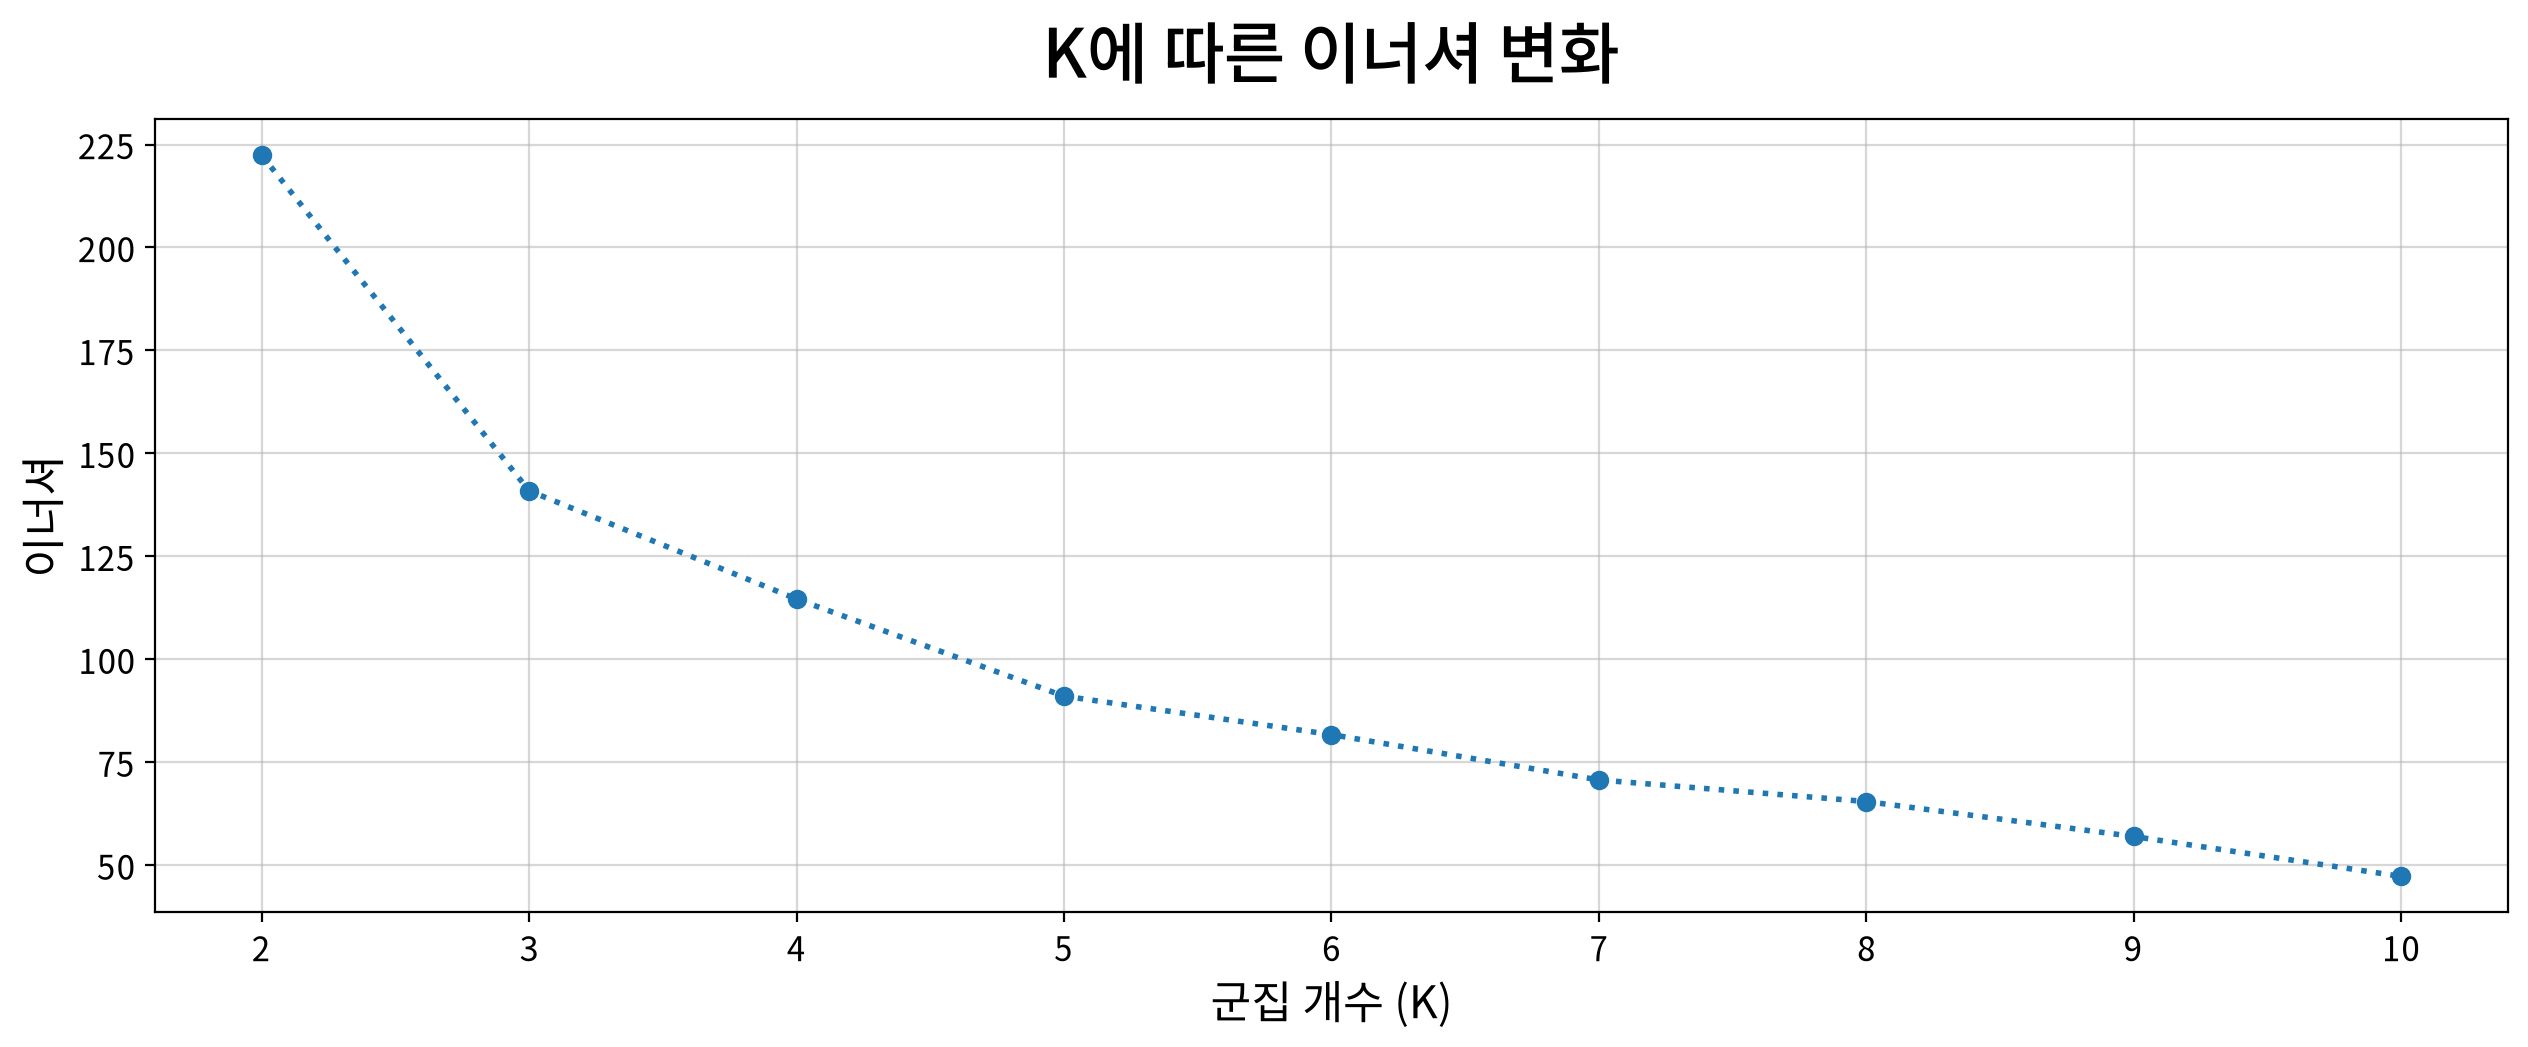

In [6]:
my_plot.lineplot(x=klist, y=inertia, marker="o", linestyle=":",
                  title="K에 따른 이너셔 변화",
                  xlabel="군집 개수 (K)", ylabel="이너셔")

- K가 커지면 이너셔는 **무조건 줄어든다**
- 그래서 이너셔가 가장 작은 K를 고르는 것은 의미가 없다.\
  **대신 줄어드는 속도가 확 꺾이는 지점**을 찾는다.
- 그래프를 보면 K가 **2 → 3**으로 갈 때는 뚝 떨어지지만,\
  그 뒤로는 완만해진다.
- **이렇게 꺾이는 지점이 팔꿈치(Elbow)를 닮았다고 해서\
  엘보우 포인트라고 부른다.**

## 엘보우 포인트 구하기

### □ KneeLocator 라이브러리 활용

◎ 주어진 파라미터가 의미하는 곡선에서 엘보우 포인트를 찾아 리턴한다.

**KneeLocator 파라미터**

| 파라미터 | 값 | 의미 |
|---|---|---|
| curve | convex | 아래로 볼록한 곡선 (이너셔 그래프의 모양) |
| curve | concave | 위로 볼록한 곡선 |
| direction | decreasing | x가 커질수록 y가 작아짐 (이너셔의 경우) |
| direction | increasing | x가 커질수록 y가 커짐 |
| S | 숫자 | 민감도. 작을수록 작은 꺾임에도 반응 |

> 엘보우 포인트는 **curve="convex", direction="decreasing", S=0.01** 형태
> (강사님이 찾은 최적값)

## #02. 엘보우 포인트 방법 
### 3. KneeLocator 라이브러리 활용 - 엘보우 포인트 구하기 

In [7]:
kl = KneeLocator(klist, inertia, curve="convex", 
                 direction="decreasing", S=0.01)

print("엘보우 포인트(자동): ", kl.elbow)
print("그 지점의 이너셔: ", round(kl.elbow_y,2))

엘보우 포인트(자동):  5
그 지점의 이너셔:  91.05


### 4. 엘보우 포인트 시각화 (결과확인)

**K=5 (Inertia=90.81)**

이너셔는 **"그룹 안에 얼마나 뭉쳤나"**만 본다.

옆 그룹과 **떨어져 있는지**는 전혀 보지 않는다.

뭉쳐 있어도 옆 그룹과 붙어 있으면 좋은 군집이 아니다.

그래서 다음 단계로 **실루엣 스코어**가 필요하다.

| 한계 | 설명 |
|---|---|
| 꺾이는 지점이 애매할 때가 많다 | 완만한 곡선이면 사람마다 다르게 읽는다 |
| 군집의 품질은 알려주지 않는다 | "잘 나뉘었는가"가 아니라 "얼마나 뭉쳤는가"만 본다 |
| 결국 후보를 좁혀줄 뿐이다 | 최종 결정은 다른 지표가 필요하다 |

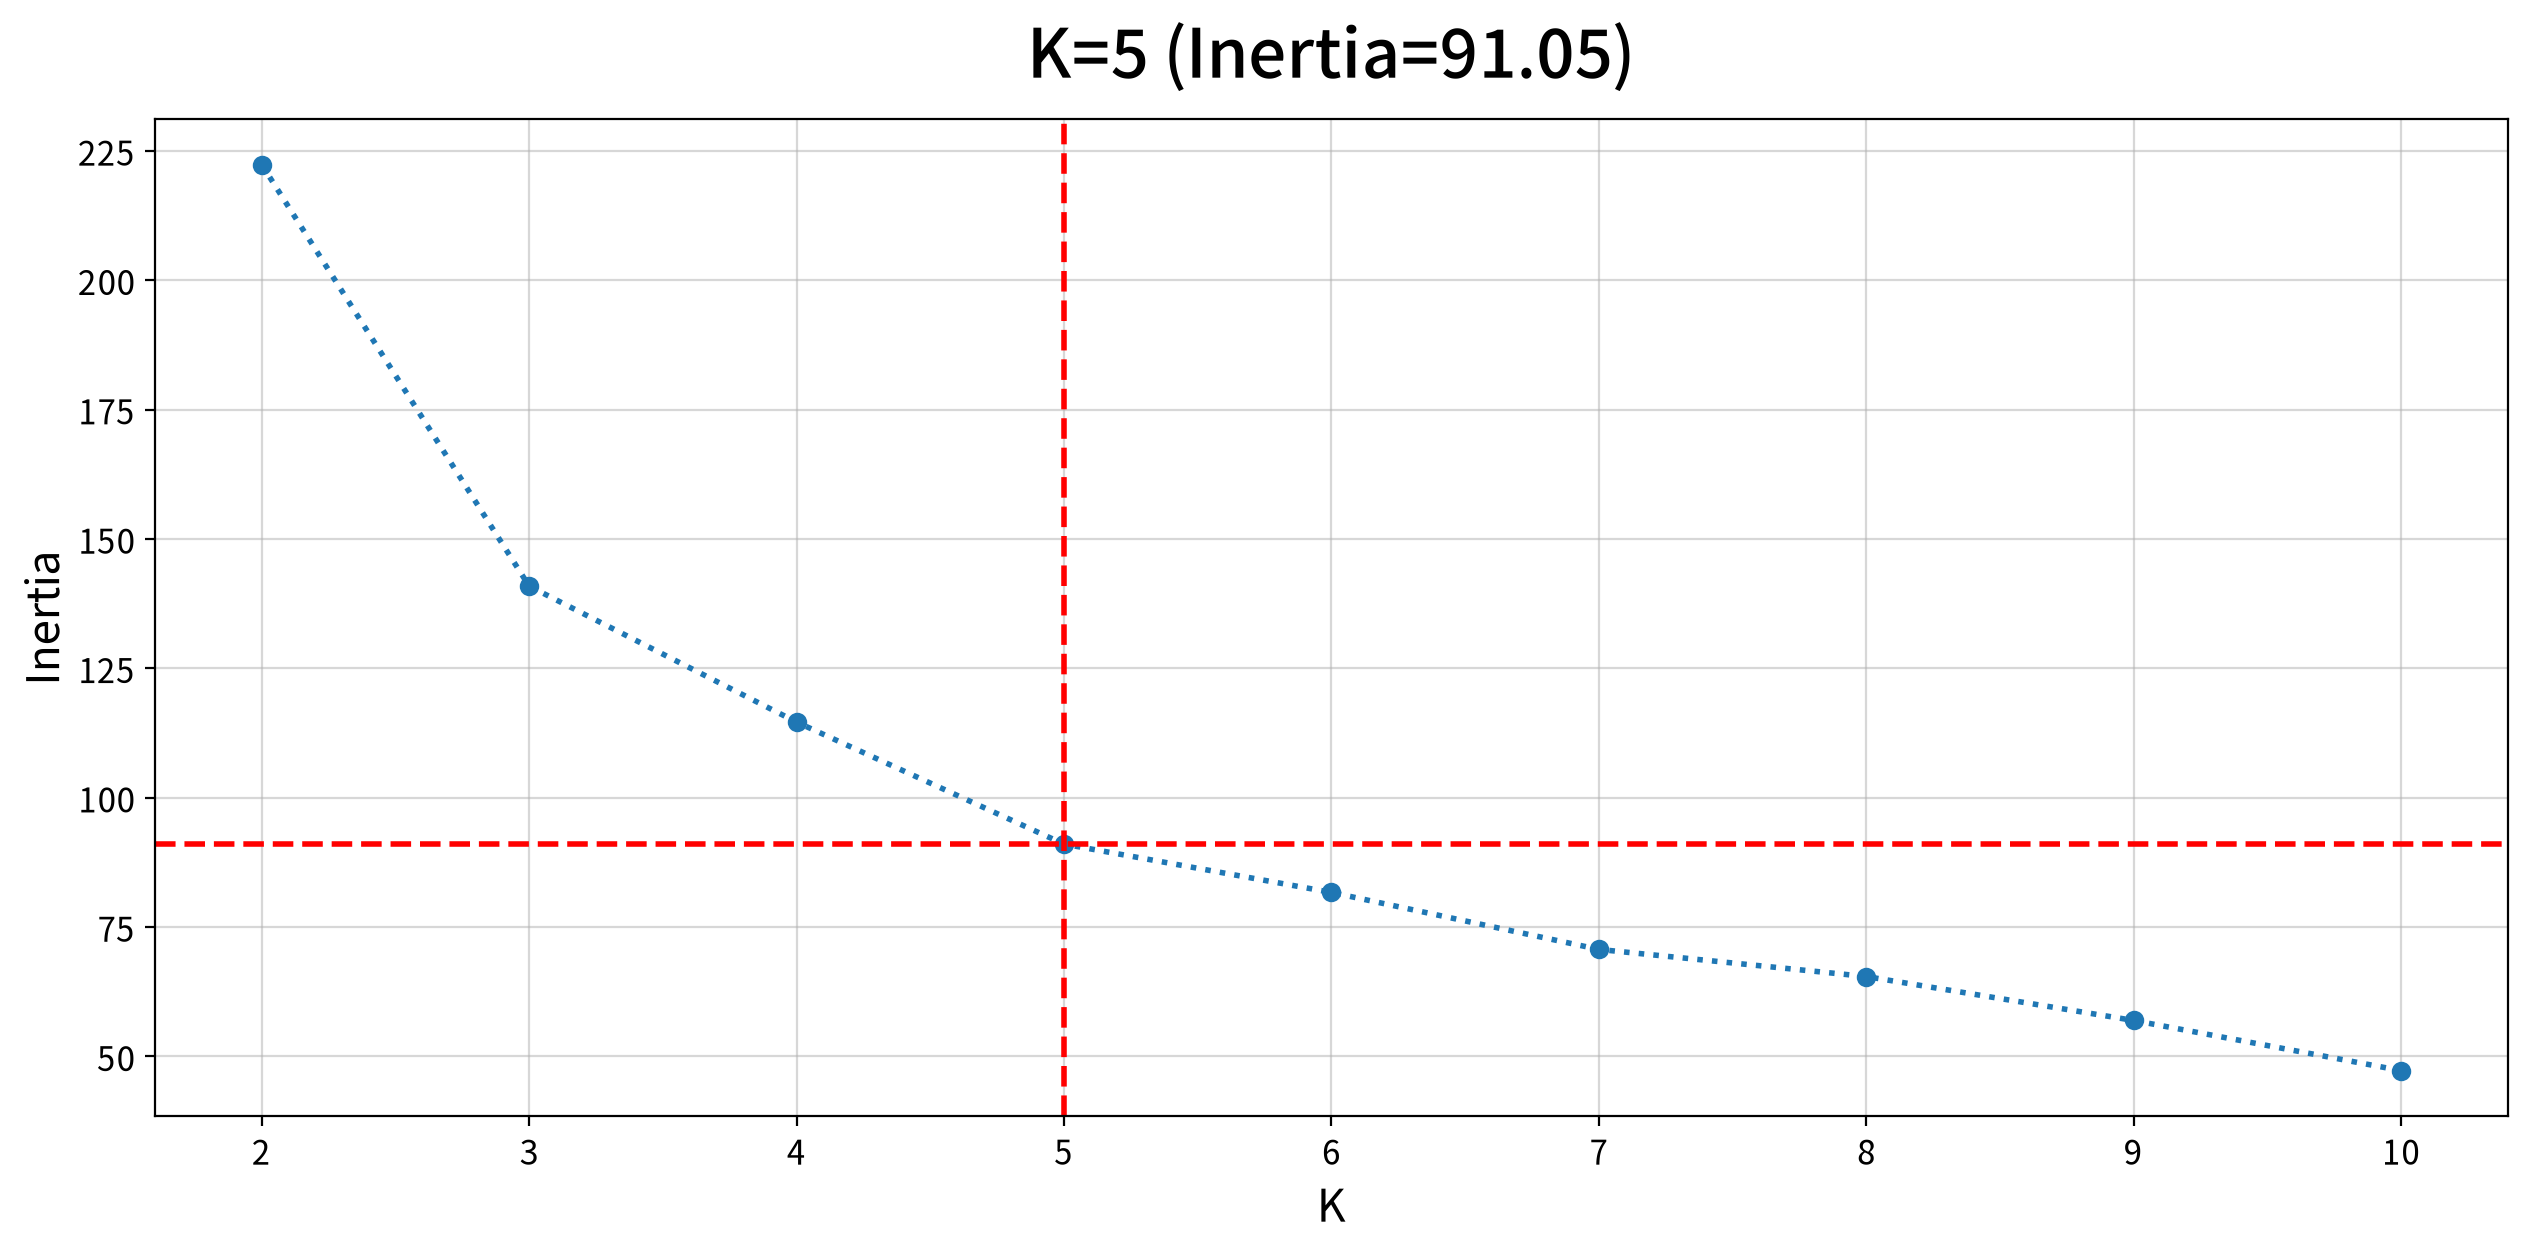

In [8]:
fig, ax = my_plot.init(
    title=f"K={kl.elbow} (Inertia={round(kl.elbow_y, 2)})",
    xlabel="K", ylabel="Inertia")

my_plot.lineplot(x=klist, y=inertia, marker="o", linestyle=":", ax=ax)

ax.axvline(x=kl.elbow, color="red", linestyle="--")
ax.axhline(y=kl.elbow_y, color="red", linestyle="--")

my_plot.show()

## #실루엣 계수와 실루엣 스코어

### □ 데이터 하나에게 "지금 그룹이 편하니, 옆 그룹이 편하니"를 묻는 지표다.

**정의**

| 기호 | 의미 |
|---|---|
| a | 나와 **같은** 그룹 친구들까지의 평균 거리 (가까울수록 좋다) |
| b | 나와 가장 가까운 **다른** 그룹 친구들까지의 평균 거리 (멀수록 좋다) |

실루엣계수 = (b - a) / max(a, b)

**값 읽는 법**

| 값 | 의미 |
|---|---|
| 1 에 가까움 | 내 그룹과 딱 붙어 있고 다른 그룹과는 멀다 → 아주 좋음 |
| 0 근처 | 내 그룹과 옆 그룹의 경계에 걸쳐 있다 → 애매함 |
| 음수 | 옆 그룹이 더 가깝다 → 잘못 묶였을 가능성 |

> 이너셔가 **a 만** 보는 지표라면, 실루엣은 **a 와 b 를 함께** 본다.

- **전체 데이터의 실루엣 계수를 평균**낸 것이 **실루엣 스코어**
- 보통 **0.5**를 넘으면 꽤 잘 나뉘었다고 본다.

## #03. 실루엣 스코어 
### 1. 데이터 하나하나의 실루엣 계수 확인 

엘로우로 확인된 K=5 상태에서 각 데이터의 실루엣 계수 확인 

In [9]:
estimator, _, _ = my_cluster.kmeans(sdf, k=5, scaling=None, 
                                    plot=None, verbose=False)

cluster = estimator.labels_

# 각 데이터 포인트의 실루엣 계수 
s_samples = silhouette_samples(X=sdf, labels=cluster)

check_df = DataFrame({"cluster":cluster, "실루엣계수":s_samples})   
check_df.head(10).T

,0,1,2,3,4,5,6,7,8,9
cluster,1.000,4.000,4.000,4.000,1.000,1.000,4.000,1.000,4.000,4.000
실루엣계수,0.352,0.630,0.593,0.656,0.443,0.567,0.236,-0.010,0.601,0.612


### 1. K=5일 때의 평균 실루엣 계수 (실루엣 스코어)

In [10]:
s_score = silhouette_score(X=sdf, labels=cluster)
print("k=5일 때의 실루엣 스코어: ", round(s_score, 4))

k=5일 때의 실루엣 스코어:  0.345


## # K를 바꿔 가며 스코어 비교

### □ K는 반드시 2부터 확인해야 하고, 막대는 세 가지를 보고 읽는다.

**K별 실루엣 스코어**

| K | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 |
|---|---|---|---|---|---|---|---|---|---|
| 실루엣 스코어 | 0.582 | 0.460 | 0.384 | 0.342 | 0.326 | 0.326 | 0.323 | 0.366 | 0.351 |

- 실루엣은 **K가 작을수록 높게 나오는 경향**이 있어, 범위를 3부터 잡으면 진짜 최고점을 놓친다.
- 최고점은 **K = 2, 0.582**

**막대 그래프 읽는 법**

| 보는 것 | 좋은 신호 |
|---|---|
| 막대가 빨간 점선(평균)을 넘는가 | 넘는 군집이 많을수록 |
| 막대의 두께(= 군집 크기)가 고른가 | 한 군집만 유난히 크면 나쁨 |
| 음수 구간이 있는가 | 없을수록 |

> 이 세 가지는 지금은 눈으로 읽는 기준이다

## # 실루엣 스코어 시각화 함수 (1)

### □ visualize_silhouette 함수

◎ scikit-learn 레퍼런스에 소개되어 있는 시각화 코드

> 수업에 제공되는 visualize_silhouette.py는 이 소스코드를 helper 라이브러리에 맞게 각색한 코드임

## # 실루엣 스코어 시각화 함수 (2)

### □ 제공되는 visualize_silhouette.py.txt의 소스코드를 my_cluster.py에 추가

◎ 통째로 복사해서 실습중인 모듈에 적용하세요.

출처: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

### 3. K를 바꿔가며 실루엣 스코어 비교 

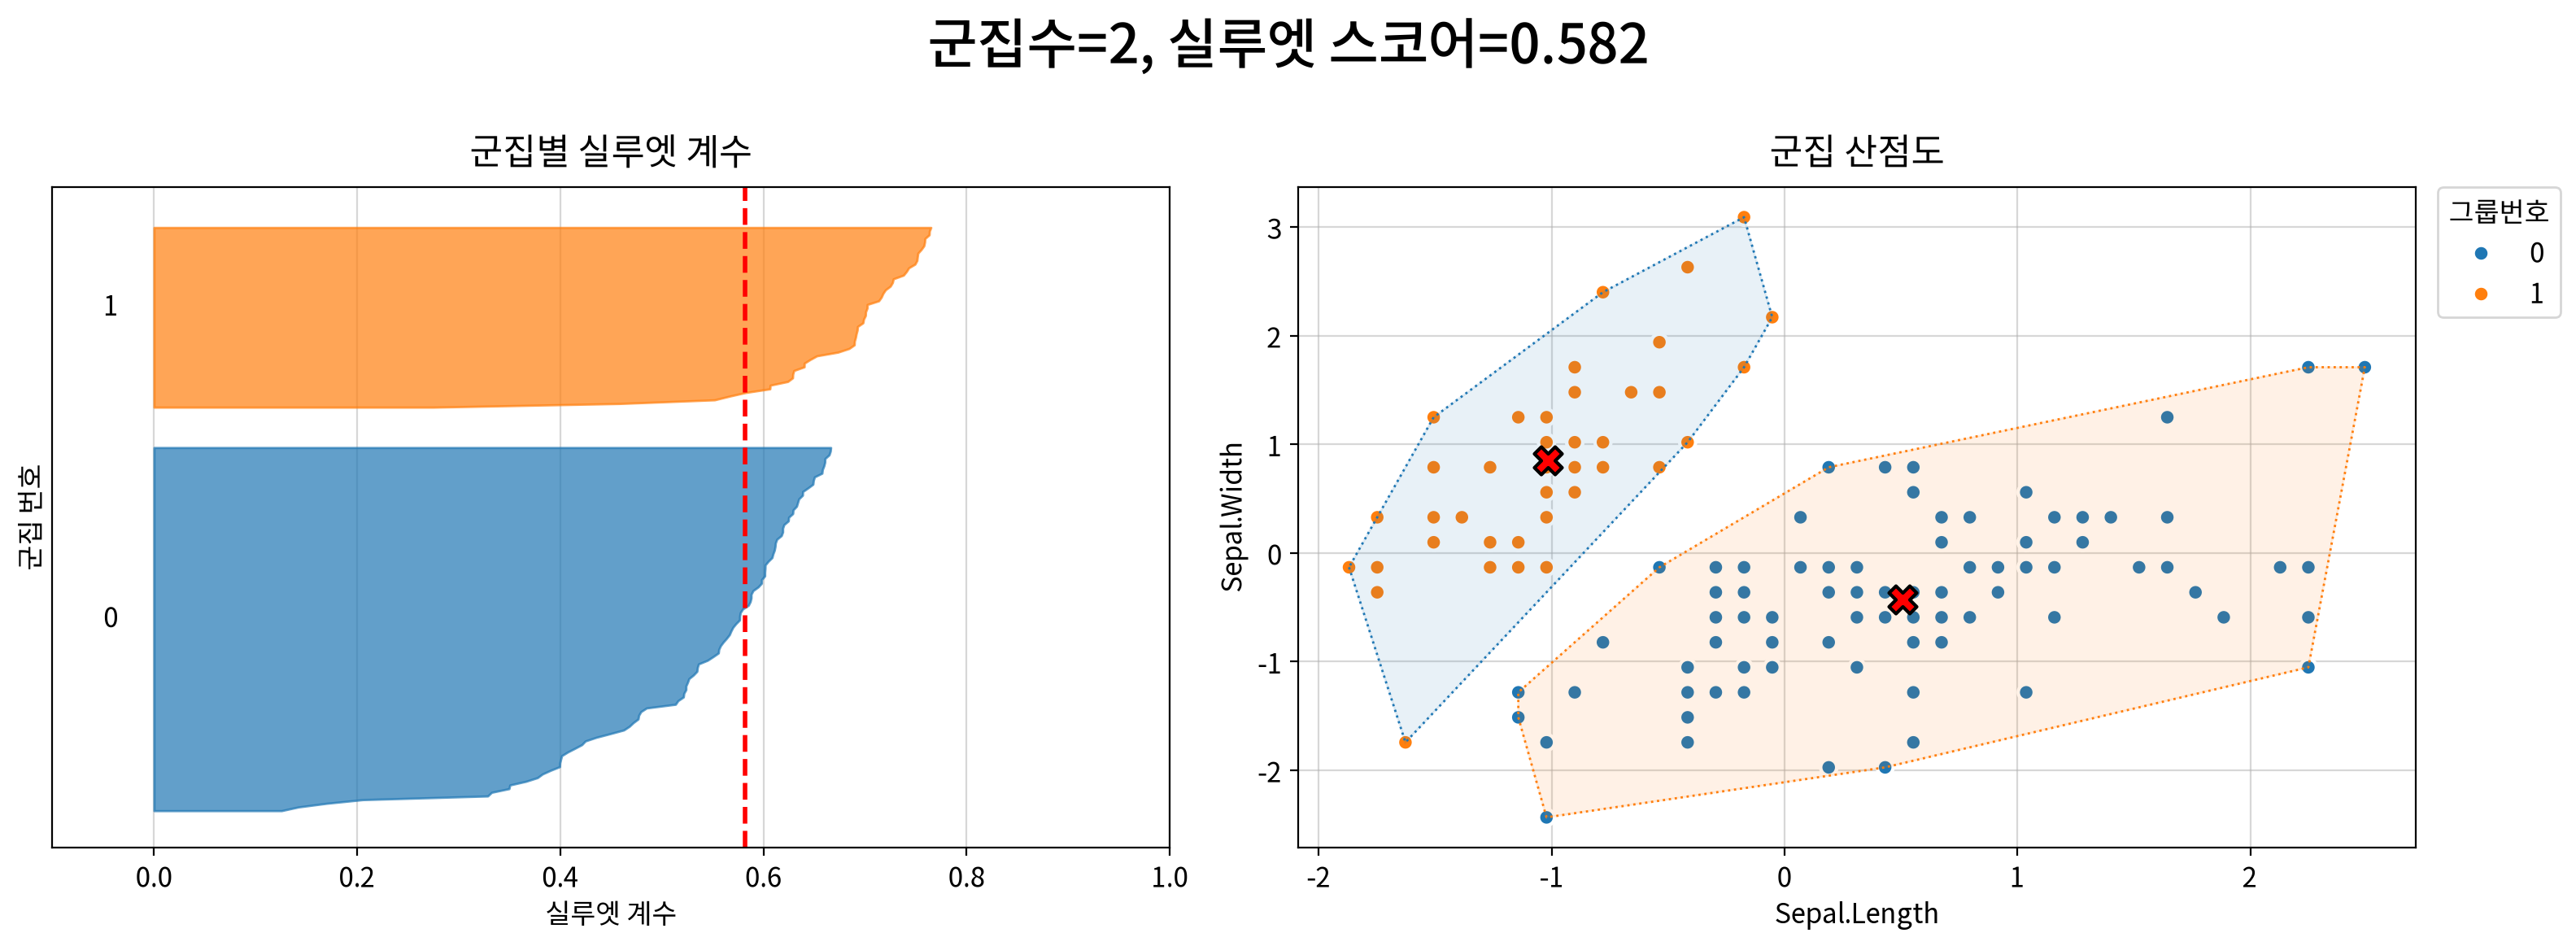

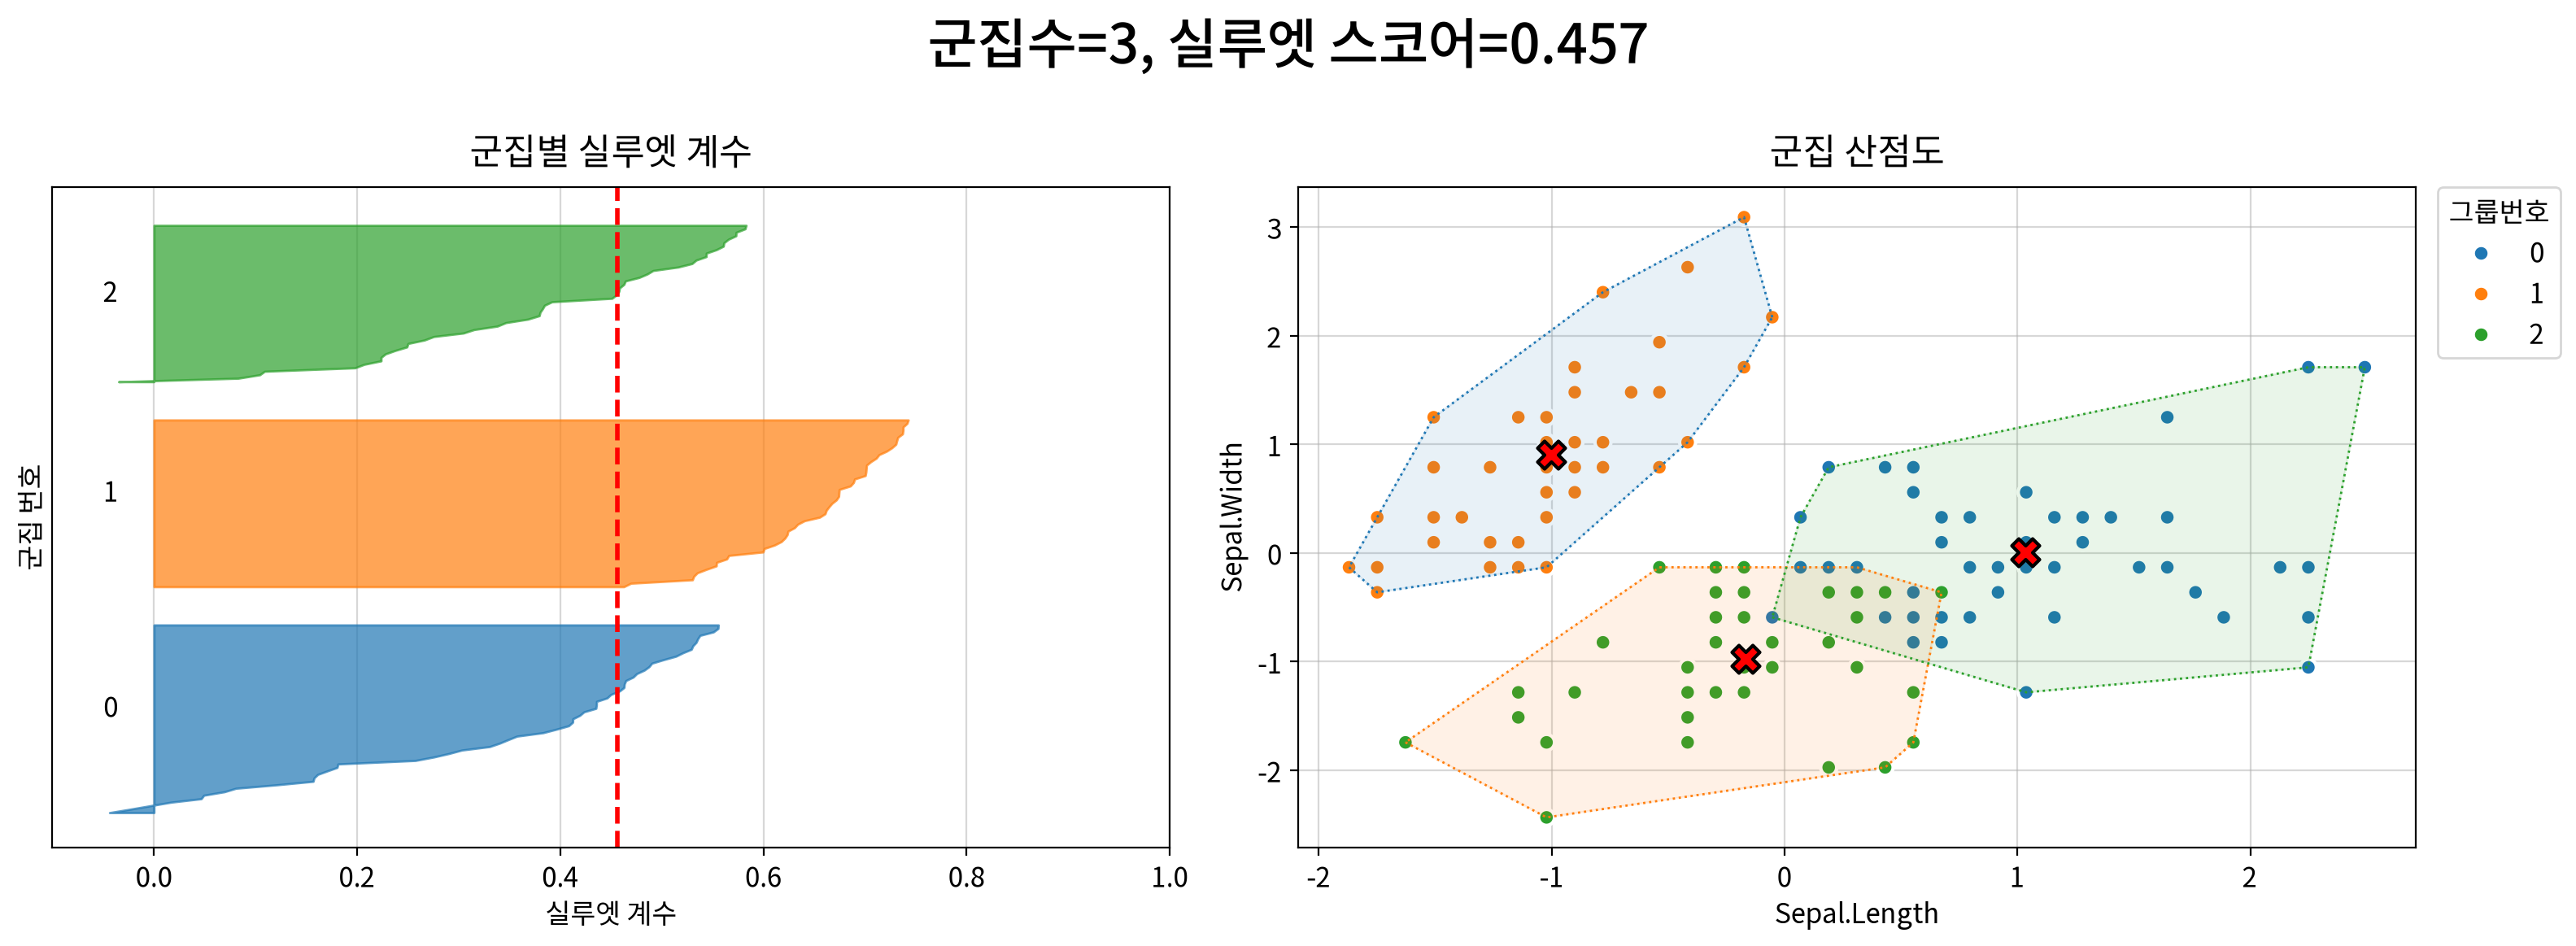

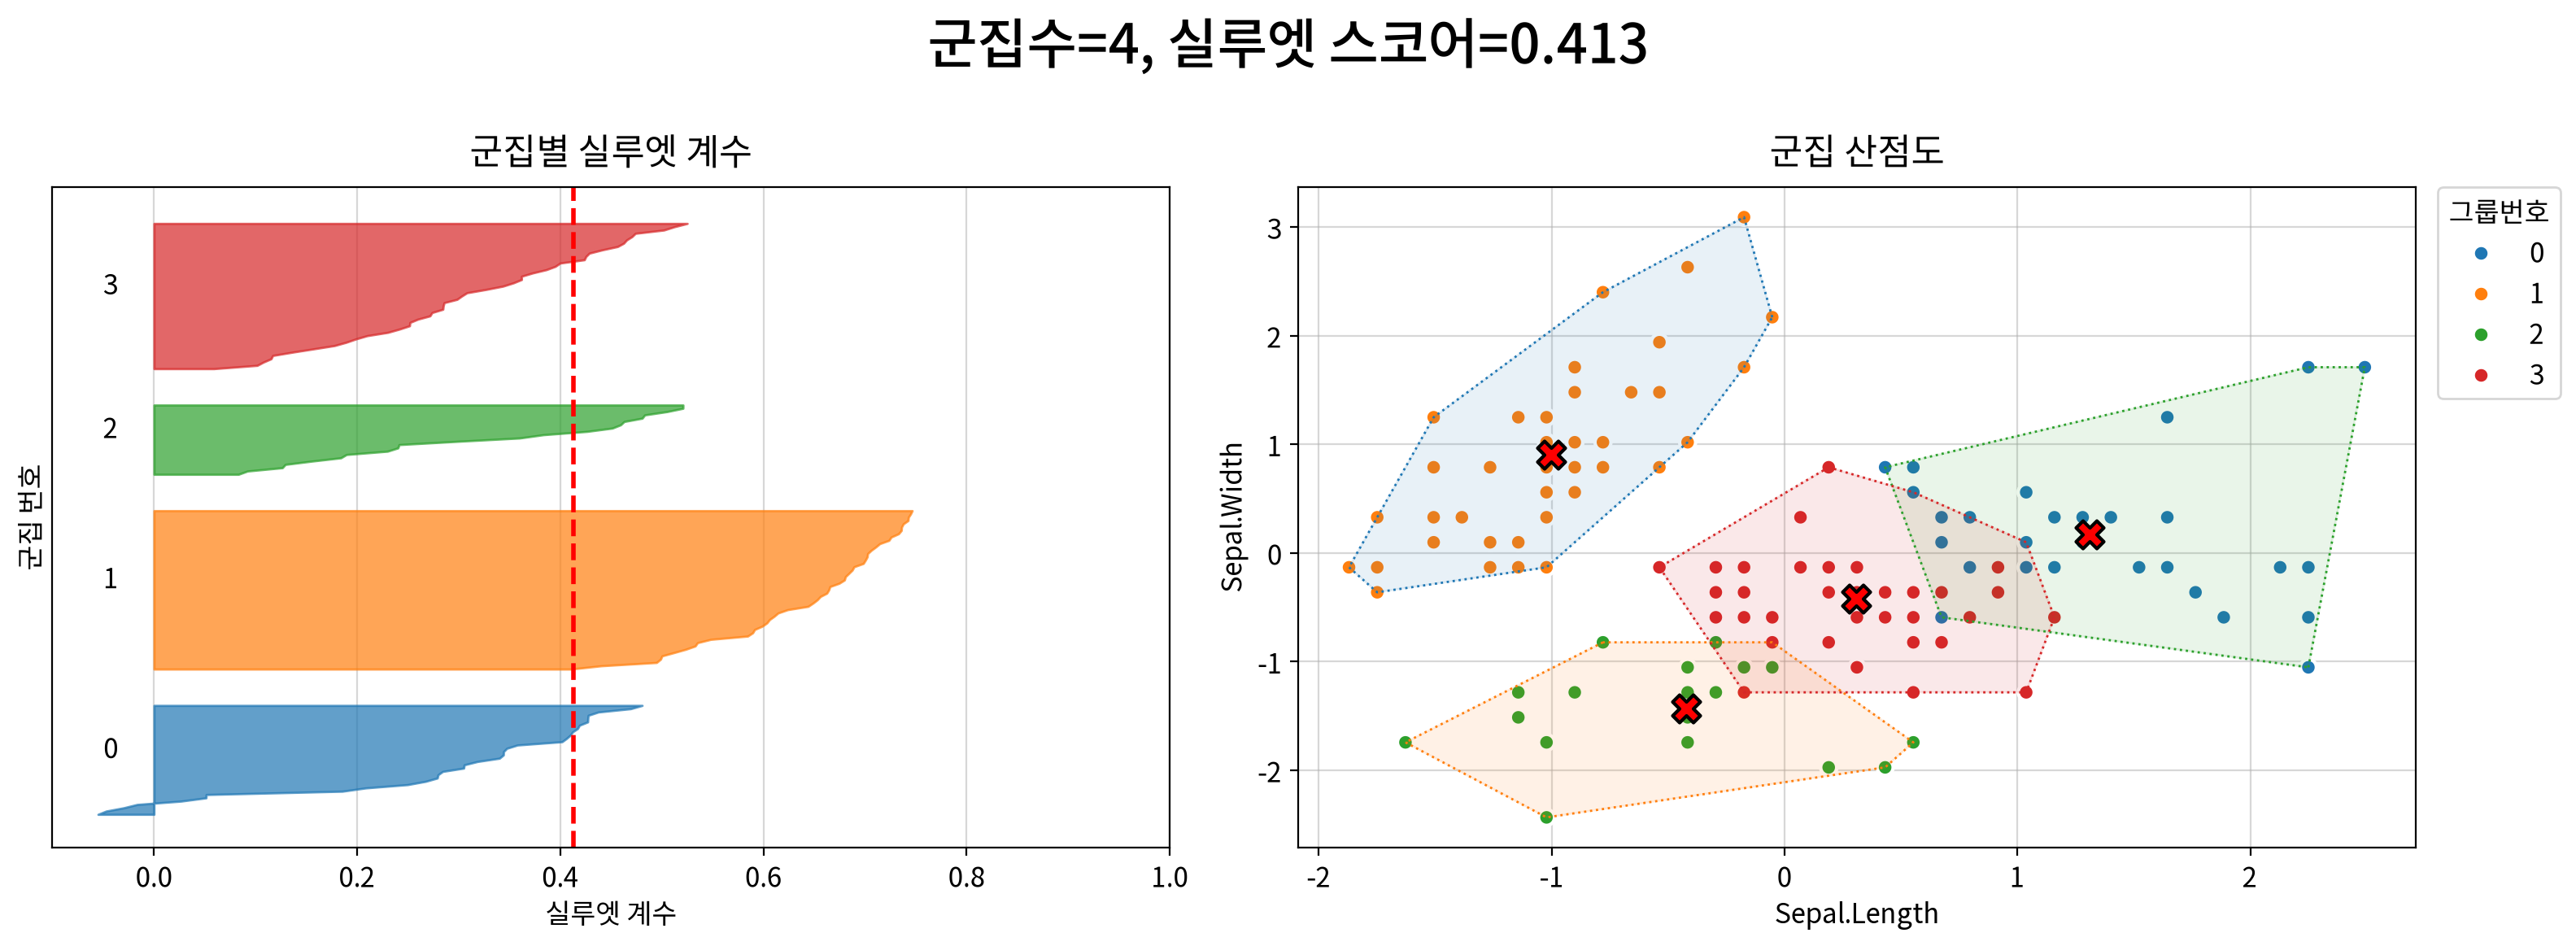

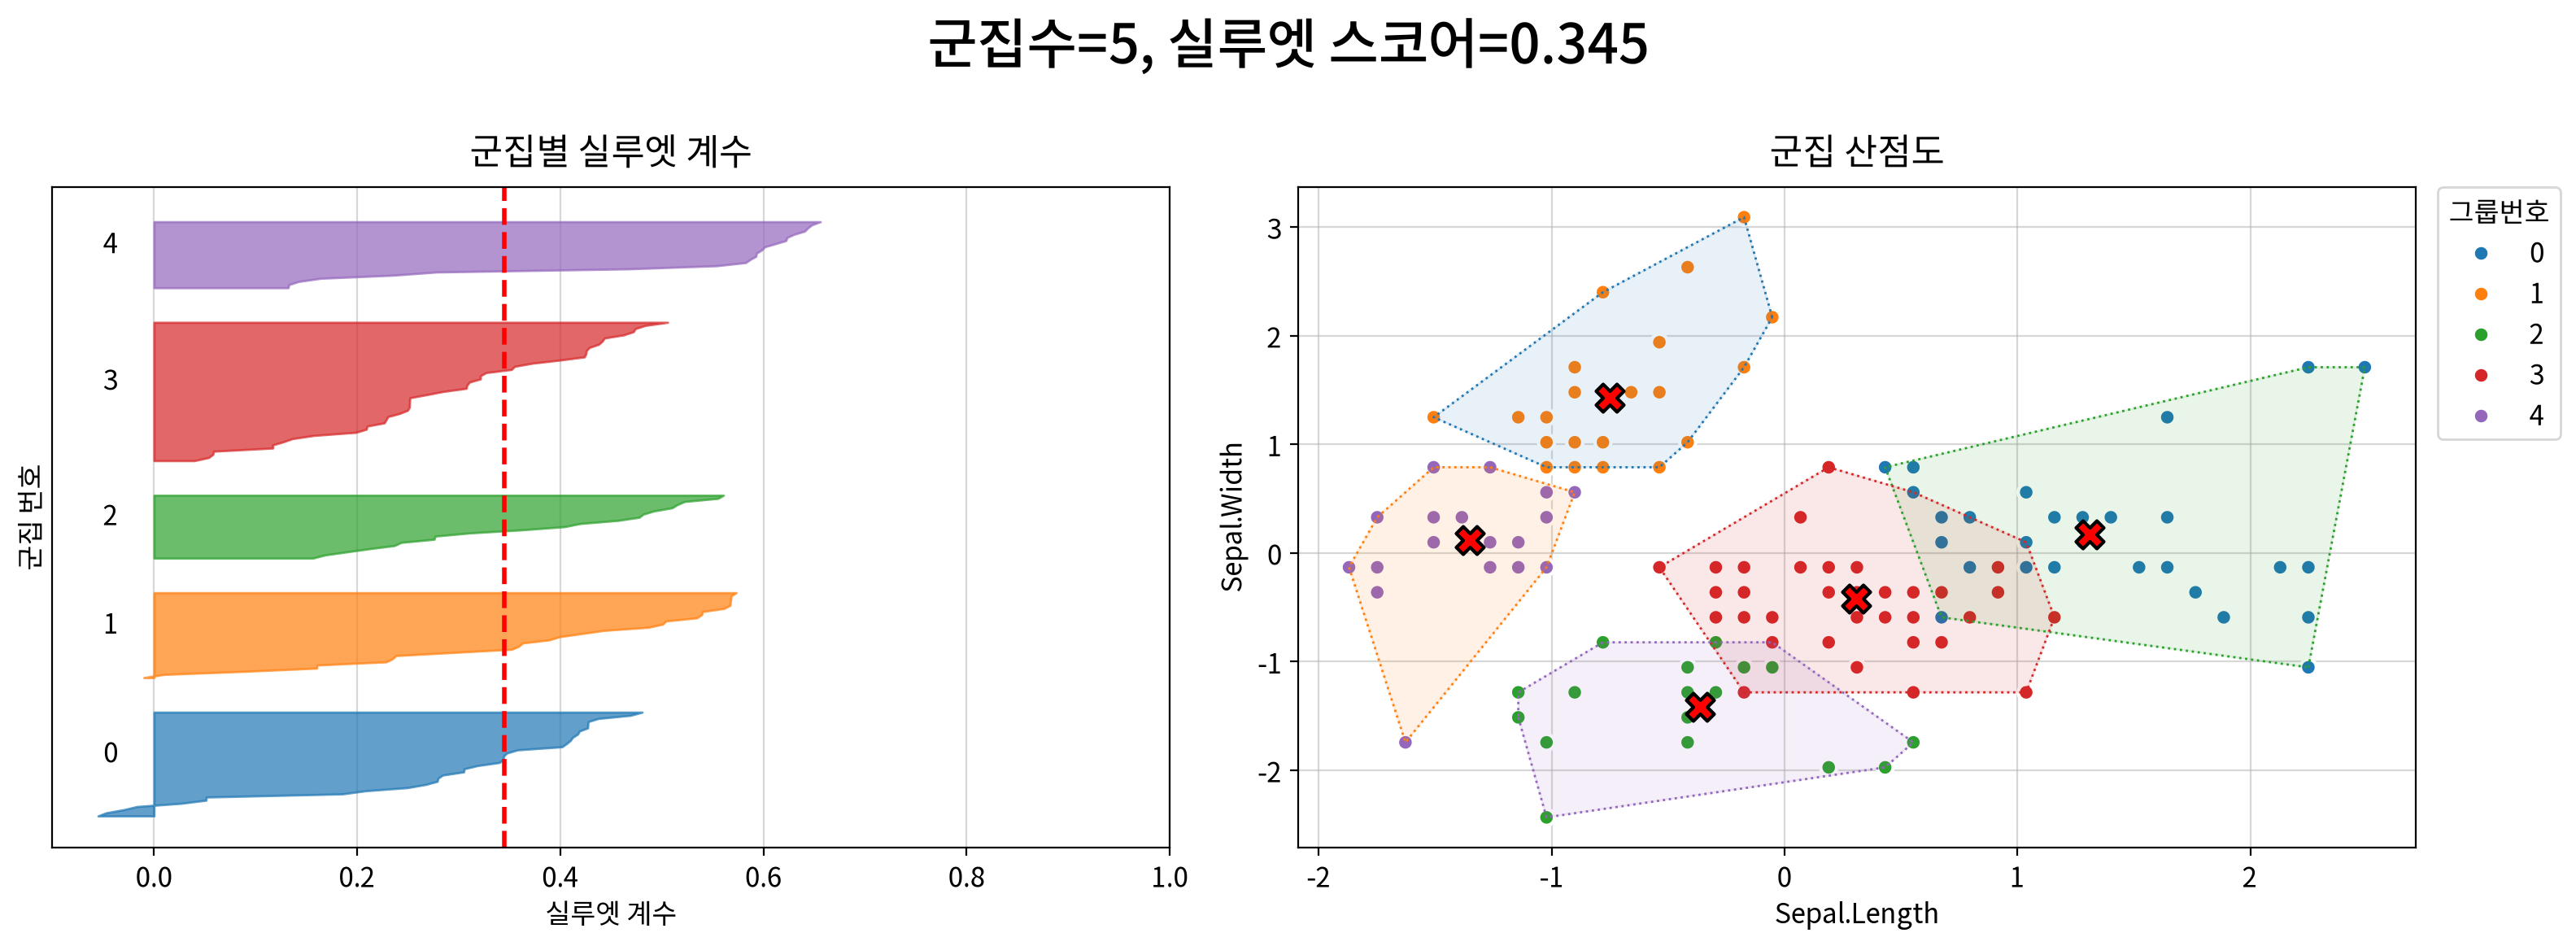

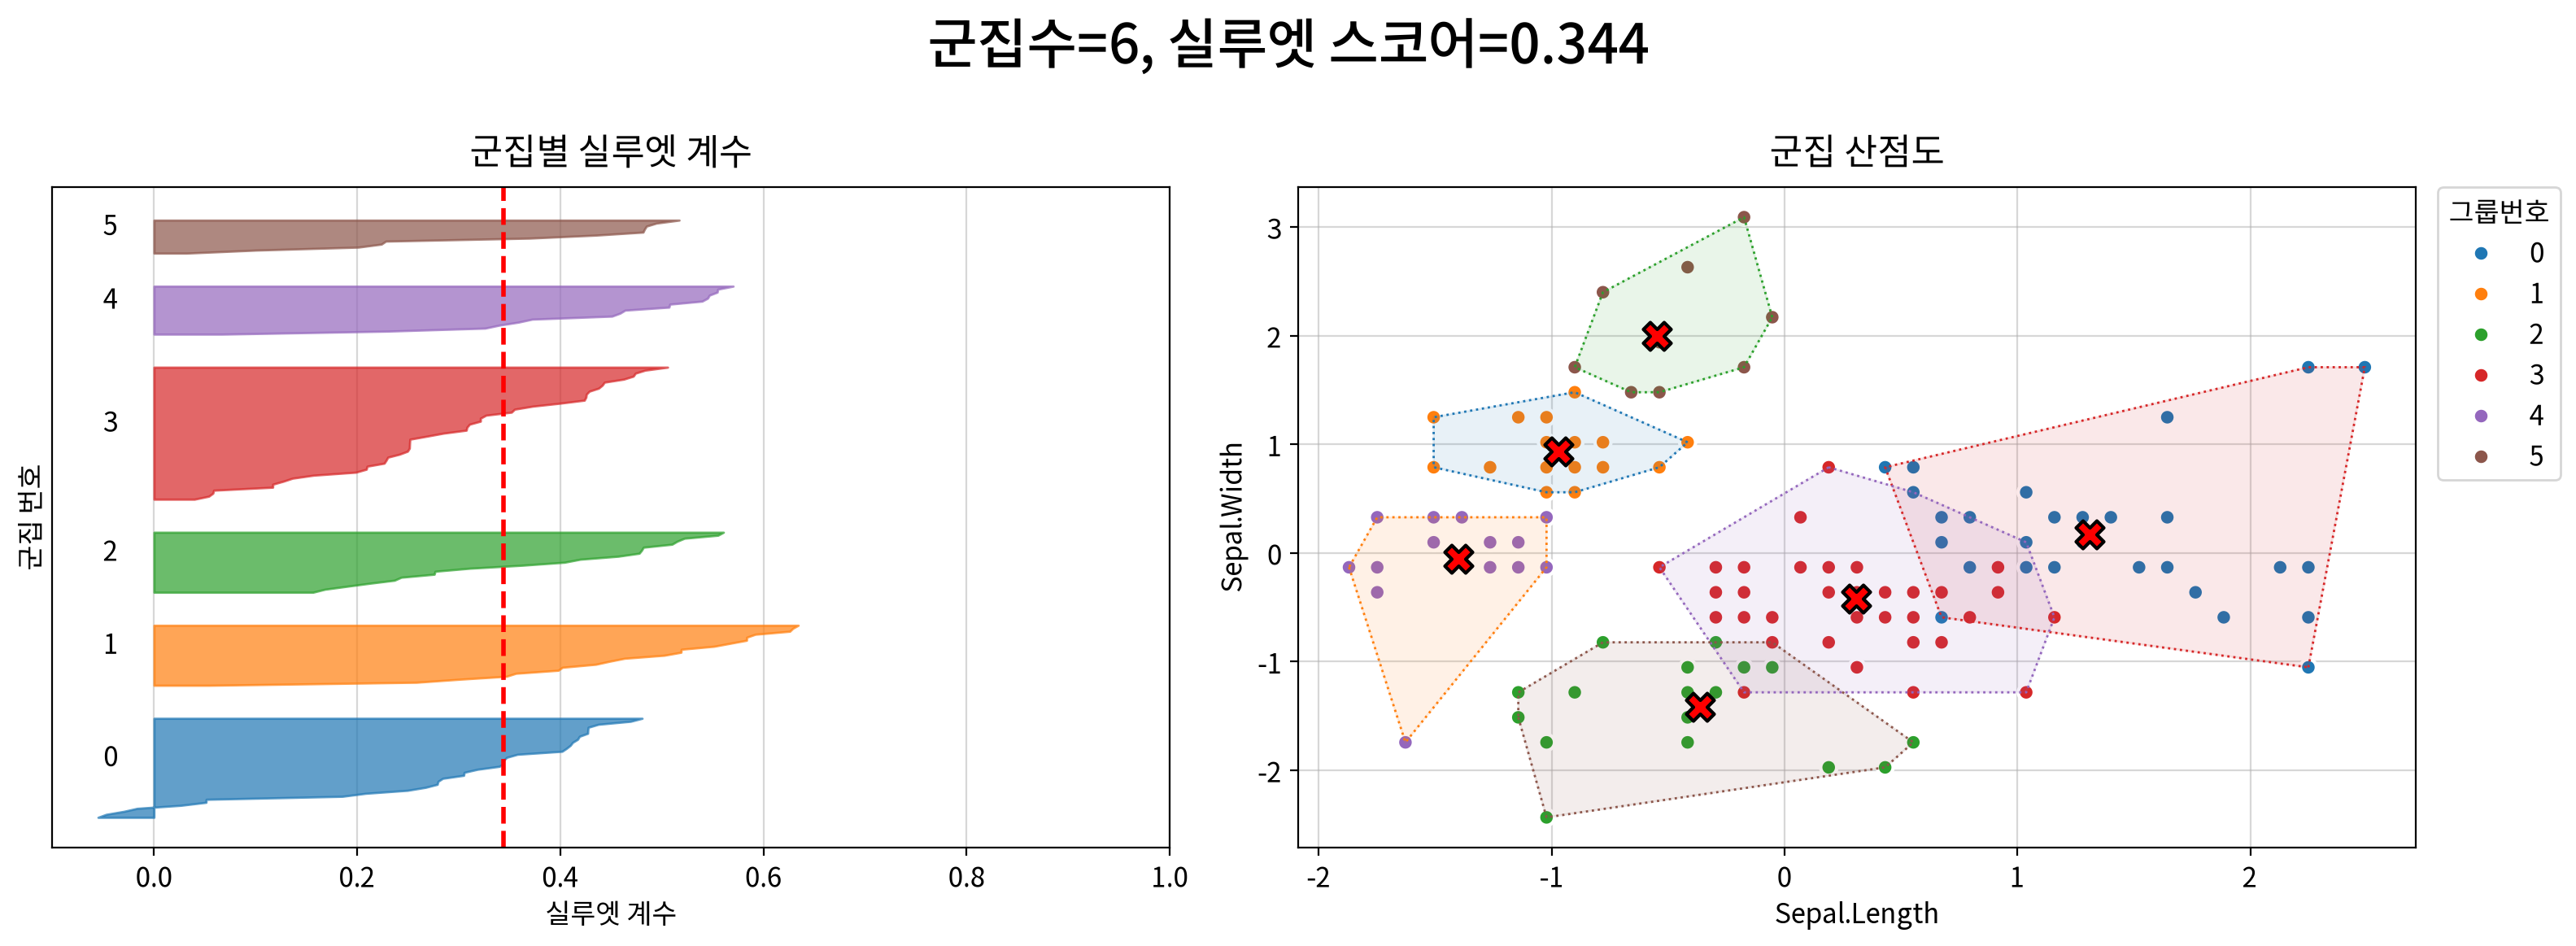

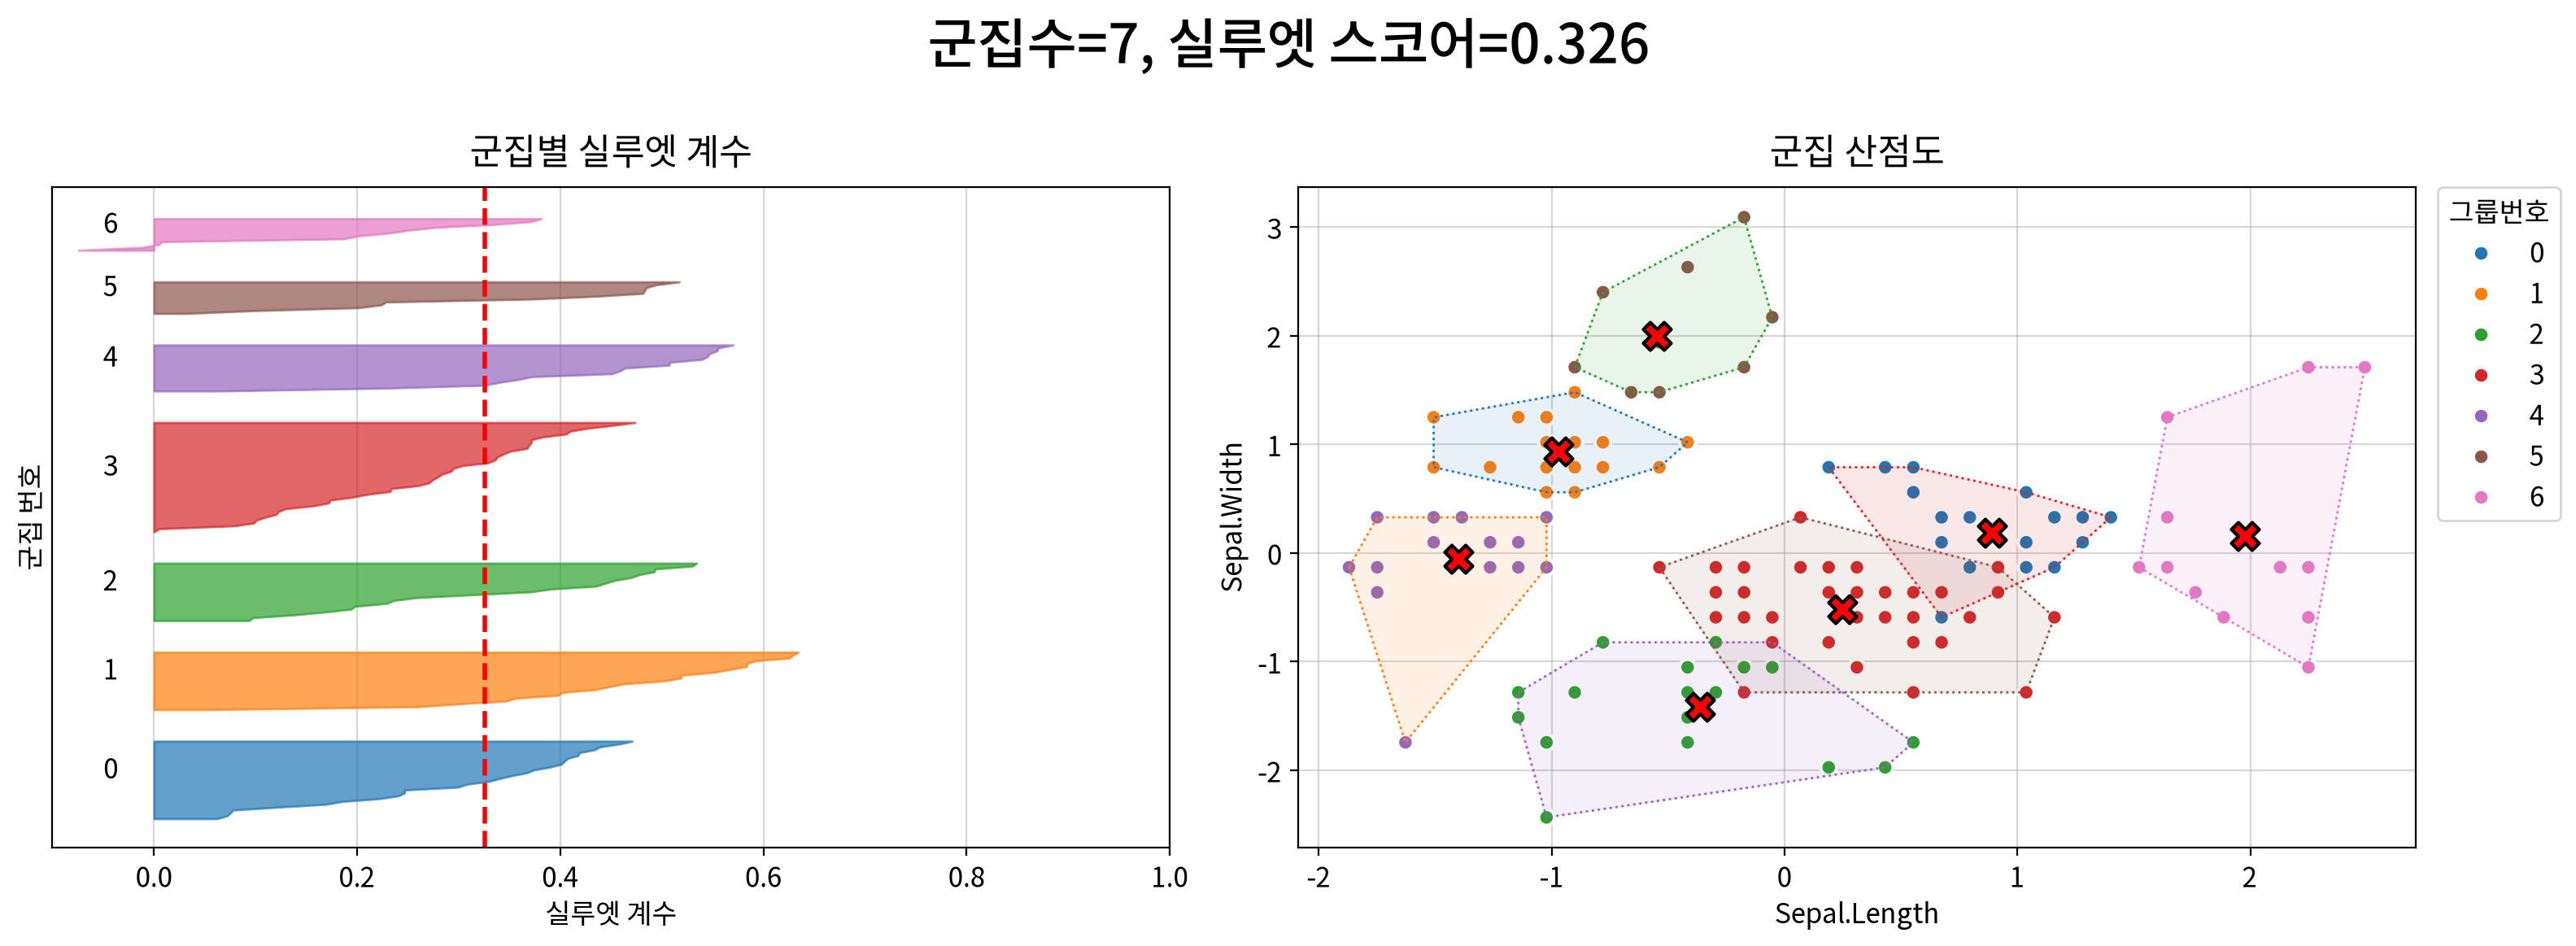

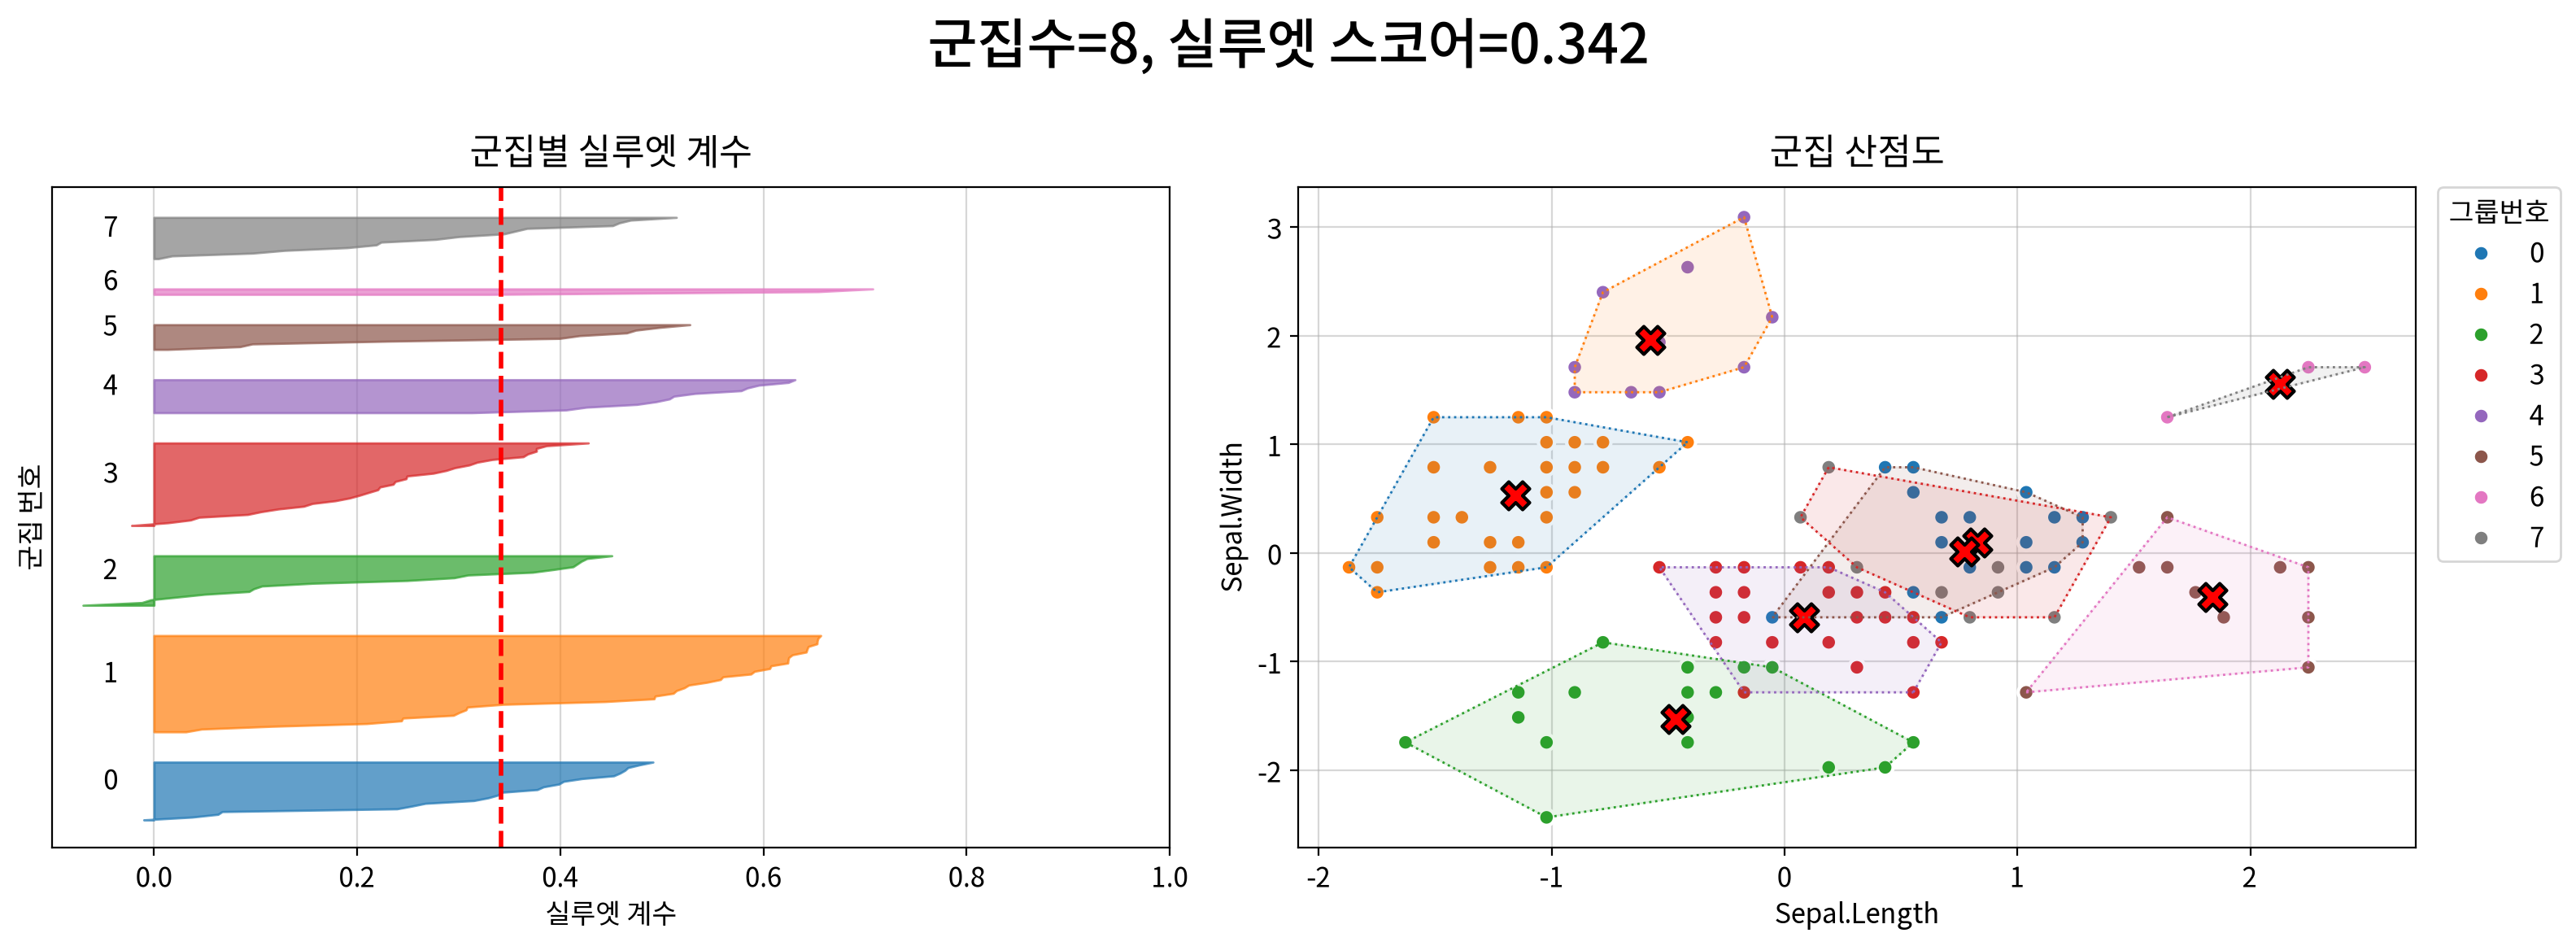

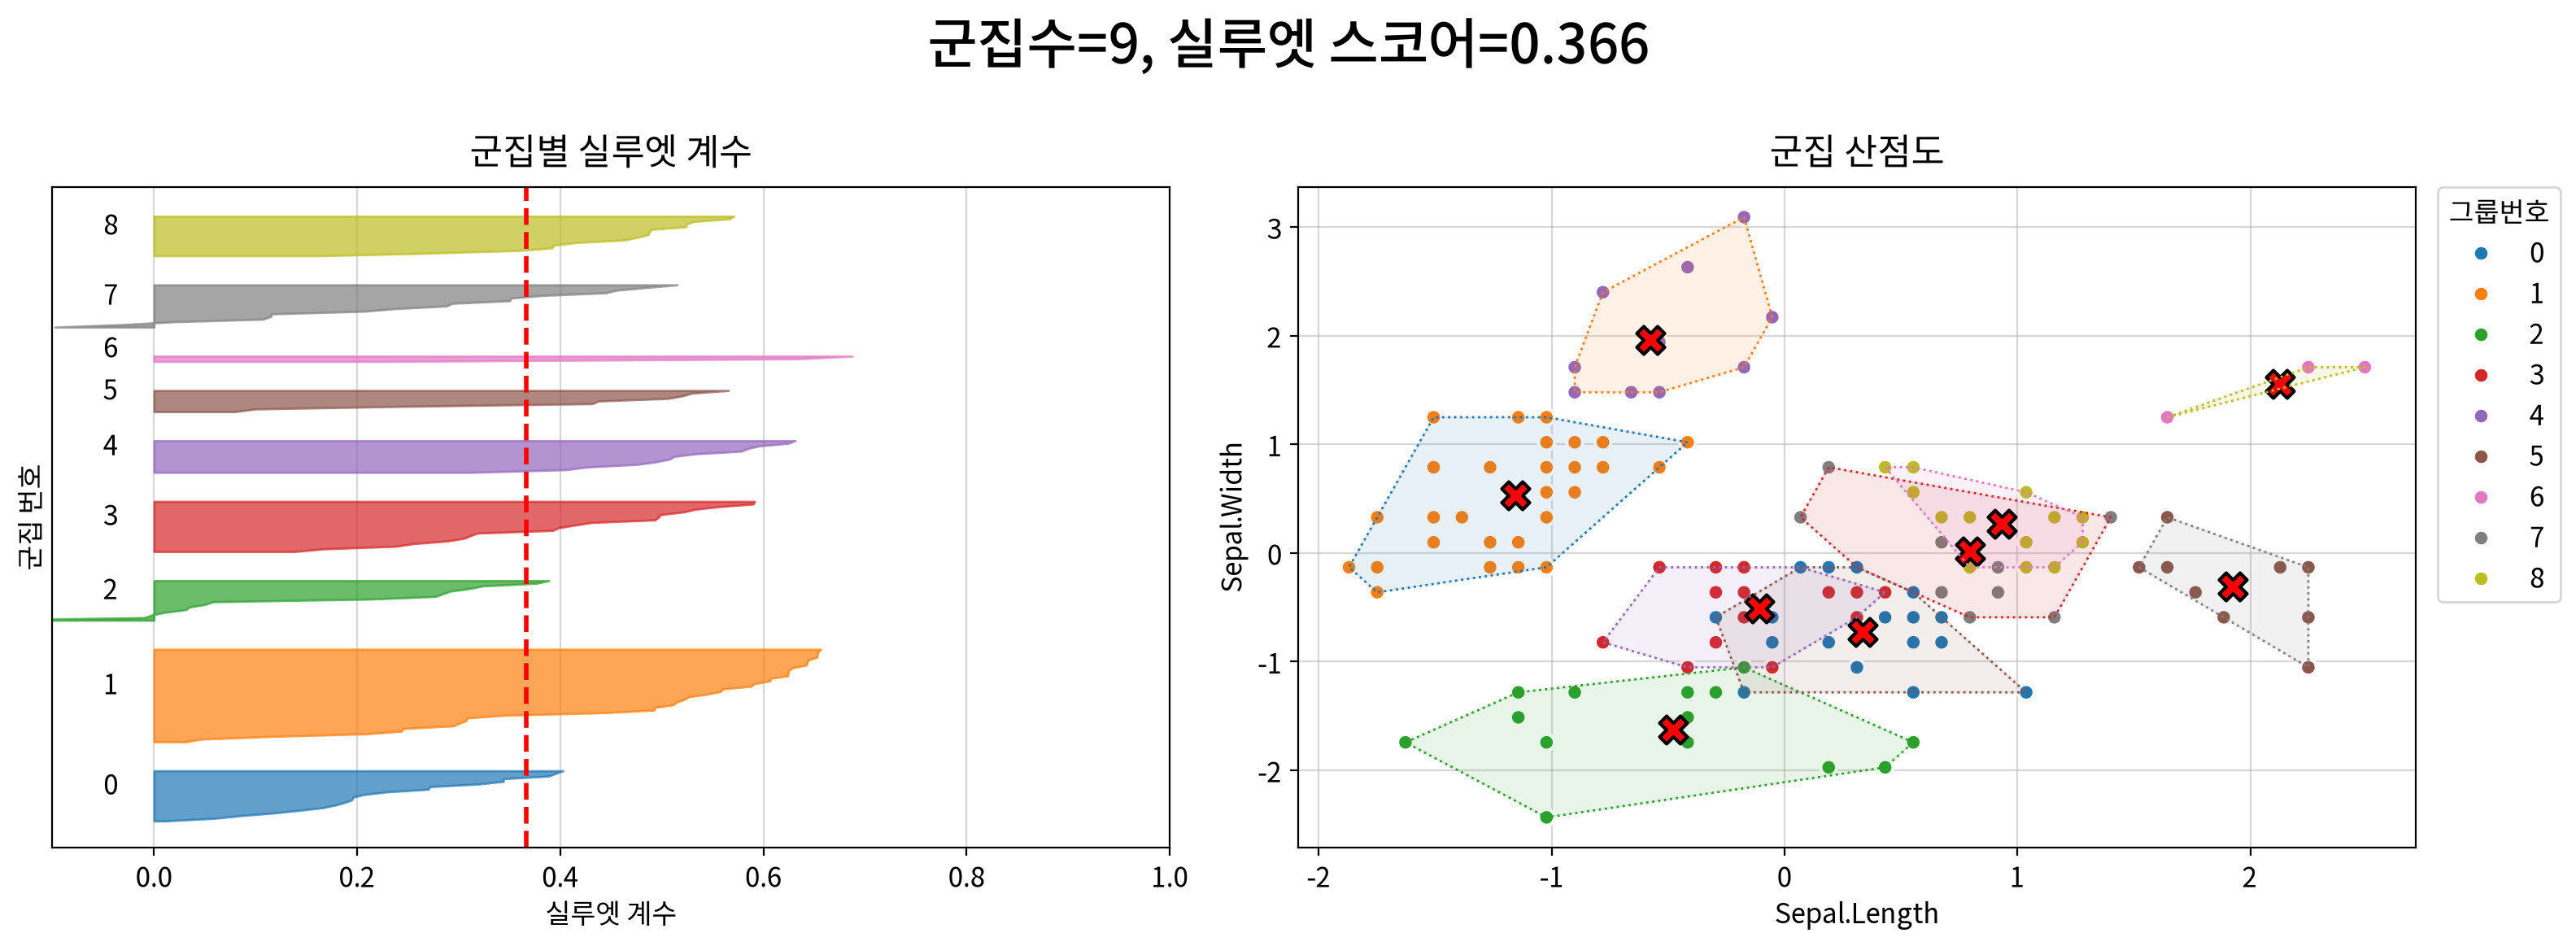

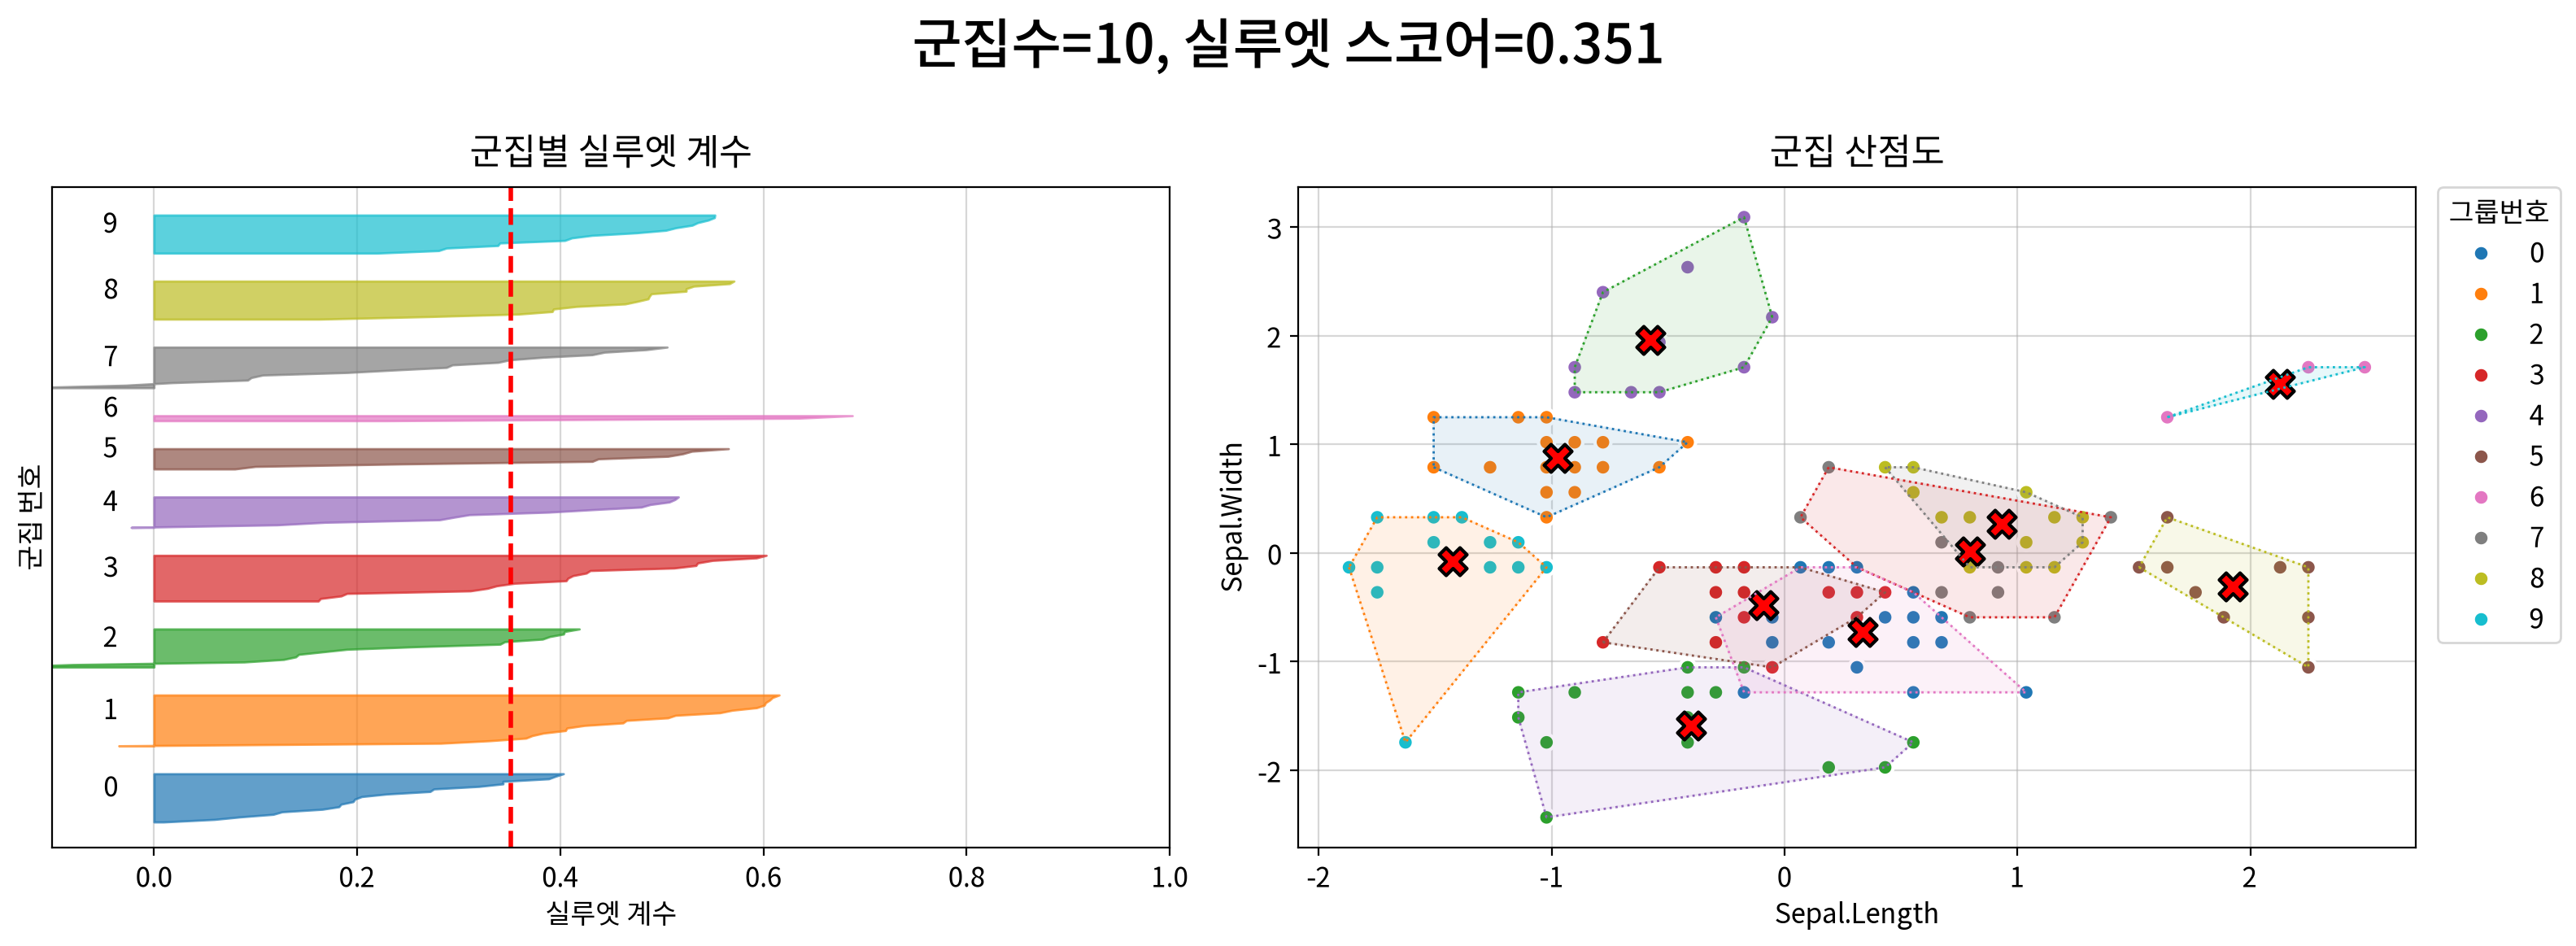

,0,1,2,7,8,3,4,6,5
k,2.000,3.000,4.000,9.000,10.000,5.000,6.000,8.000,7.000
score,0.582,0.457,0.413,0.366,0.351,0.345,0.344,0.342,0.326


In [11]:
s_items = []

for k in klist:
    estimator, _, _ = my_cluster.kmeans(sdf, k=k, scaling=None, 
                                        plot=False, verbose=False)

    cluster = estimator.labels_

    my_cluster.visualize_silhouette(estimator, sdf) # 실루엣 시각화 
    s_score = silhouette_score(X=sdf, labels=cluster) # 실루엣 스코어 

    s_items.append({"k":k, "score":round(s_score, 4)})

score_df = DataFrame(s_items).sort_values(by="score", ascending=False)  
score_df.T

## # 막대의 면적으로 K 고르기

### □ 실루엣 스코어는 "막대 전체의 면적" → 면적은 길이와 두께로 나뉜다.

**면적의 의미**
- 왼쪽 막대는 데이터 하나를 **가로 = 실루엣 계수, 세로 두께 = 1**인 띠로 쌓은 그림
- 한 군집의 면적 = **그 군집 계수의 합**

> 실루엣 스코어는 "**칼날 전체 면적을 데이터 개수로 나눈 값**"
> 스코어가 높다 = 칼날이 오른쪽으로 넓게 뻗어 있다

**같은 면적, 다른 의미**

| 만들어진 방식 | 의미 |
|---|---|
| 얇은데 길다 | 작은 군집이 아주 잘 나뉘었다 → 좋은 신호 |
| 두꺼운데 짧다 | 큰 군집이 애매하게 뭉쳐 있다 → 나쁜 신호인데 평균 점수는 높게 나옴 |

**판정 방법**

| 보는 것 | 계산 | 좋은 값 |
|---|---|---|
| ① 전체면적 | 모든 실루엣 계수의 합 (= 150 × 스코어) | 클수록 좋다 |
| ② 두께비 | 가장 큰 군집 크기 ÷ 가장 작은 군집 크기 | 1에 가까울수록 좋다 |
| ③ 최소상대면적 | (가장 작은 막대의 면적 점유율) ÷ (1/K) | 1에 가까울수록 좋다. 0에 가까우면 있으나 마나 한 군집 |

> **1/K 로 나누는 이유**: K개 군집이 면적을 공평하게 나눠 가지면 각자 1/K 씩 갖는다.
> "공평한 몫의 몇 배인가"로 바뀌어야 K가 다른 경우끼리 비교할 수 있다.

In [12]:
area_items = []

for k in klist:
    estimator, _, _ = my_cluster.kmeans(sdf, k=k, scaling=None, plot=False, verbose=False)
    cluster = estimator.labels_

    # 데이터 하나하나의 실루엣 계수 (= 얇은 띠 하나의 가로 길이)
    s_samples = silhouette_samples(X=sdf, labels=cluster)

    # 군집별 면적(계수의 합)과 두께(데이터 개수)
    area = np.array([s_samples[cluster == c].sum() for c in range(k)])
    size = np.array([(cluster == c).sum() for c in range(k)])

    area_items.append({
        "k": k,
        "스코어": round(s_samples.mean(), 3),      # 계수의 평균 = 실루엣 스코어
        "전체면적": round(area.sum(), 1),           # 계수의 합 = 150 × 스코어
        "두께비": round(size.max() / size.min(), 2),
        "최소상대면적": round(area.min() / area.sum() * k, 2),
    })

area_df = DataFrame(area_items)
area_df

,k,스코어,전체면적,두께비,최소상대면적
0,2,0.582,87.300,2.000,0.780
1,3,0.457,68.500,1.200,0.770
2,4,0.413,62.000,2.230,0.450
3,5,0.345,51.800,2.140,0.760
4,6,0.344,51.600,3.750,0.470
5,7,0.326,48.800,3.250,0.310
6,8,0.342,51.300,12.000,0.260
7,9,0.366,54.900,12.000,0.250
8,10,0.351,52.700,7.000,0.290


## #03. 실루엣 스코어

### 4. 막대의 면적으로 K 고르기 (결과확인)

◎ 면적을 크게 잃지 않으면서 두께가 고른 마지막 K가 3 이다.

| k | 스코어 | 전체면적 | 두께비 | 최소상대면적 |
|---|---|---|---|---|
| 0 | 2 | 0.582 | 87.300 | 2.000 | 0.780 |
| 1 | 3 | 0.460 | 69.000 | 1.130 | 0.710 |
| 2 | 4 | 0.383 | 57.500 | 2.080 | 0.650 |
| 3 | 5 | 0.342 | 51.300 | 2.090 | 0.800 |
| 4 | 6 | 0.326 | 48.900 | 3.080 | 0.290 |
| 5 | 7 | 0.326 | 48.800 | 3.250 | 0.310 |
| 6 | 8 | 0.322 | 48.400 | 4.860 | 0.260 |
| 7 | 9 | 0.366 | 54.900 | 12.000 | 0.250 |
| 8 | 10 | 0.351 | 52.700 | 7.000 | 0.290 |

- **K = 2**: 면적은 가장 넓지만 막대 하나가 나머지의 2배로 두껍다 (100 : 50)
- **K = 3**: 면적 2위 + 두께가 전 구간에서 가장 고르다 (53 : 50 : 47)
- **K = 4**는 세 지표가 한꺼번에 나빠지고,
- **K = 6**은 면적 점유율 5% 짜리 막대가 생기며,
- **K = 9**는 두께비가 12배다.

**K = 2 → 3 : 맞바꿀 것이 있다**
- 전체면적 87.3 → 69.0 (21% 감소)
- 두께비 2.00 → 1.13
→ 면적을 내주고 균형을 얻는다.

K = 2 의 두꺼운 막대(100개)는 평균 계수 0.532 로 전체 평균선 0.582 에 미달
= 아직 덜 쪼갠 덩어리

**K = 3 → 4 : 맞바꿀 것이 없다**
- 전체면적 69.0 → 57.5 (17% 감소)
- 두께비 1.13 → 2.08
- 최소상대면적 0.71 → 0.65
→ 세 지표가 전부 나빠진다. 더 쪼갤 이유가 없다.

면적과 두께비는 이후 K = 5~10 에서도 K = 3 수준으로 회복되지 않는다.

## 네 지표 비교

### □ 점수 1등을 고르는 대신 후보를 하나씩 지운다.

| 구분 | 이너셔 | 엘보우 | 실루엣 스코어 | 실루엣 면적 |
|---|---|---|---|---|
| 해석 관점 | 그룹 안에 얼마나 뭉쳤나 | 이너셔가 꺾이는 지점 | 뭉침 + 분리 | 그 분리가 군집마다 고른가 |
| 값 해석 | 상대 비교만 가능 | 눈으로 판단 (주관적) | 점수 그대로 해석 가능 | K끼리 비교해서 판단 |
| K가 커지면 | 항상 감소 | 감소폭이 완만해짐 | 오를 수도 내릴 수도 있음 | 두께 균형이 대체로 나빠짐 |
| 놓치는 것 | 그룹 간 거리 | 군집의 품질 | 군집별 크기 불균형 | — |
| 단독으로 K 결정 | ✗ | 후보만 좁힘 | △ 크기 불균형에 속을 수 있음 | ○ 가능 |

> 실무 순서 이너셔 계산 → 엘보우로 K 후보 → 실루엣 스코어로 순위 → 실루엣 면적·두께로 최종 선택

## 후보 소거와 최종 K 확정

### □ 세 지표가 서로 다른 K를 가리킨다. 하나씩 지워 남는 것을 고른다.

| 지표 | 추천 K | 근거 | 판정 |
|---|---|---|---|
| 엘보우 | 5 | 이너셔 감소폭이 꺾이는 지점 | ✗ 엘보우 후보지 면적이 51.3·48.9 로 K=3(69.0)의 71~74% 수준<br>스코어도 0.342·0.326 으로 K=3(0.460)보다 크게 낮다 |
| 실루엣 스코어 | 2 | 평균 점수가 가장 높다 (0.582) | ✗ 스코어 1위지만 막대가 100 : 50 (두께비 2.00), 두꺼운 쪽 평균 계수 0.532 가 평균선 0.582 에 미달<br>→ 아직 덜 쪼갠 상태 |
| 실루엣 면적 | 3 | 면적을 크게 잃지 않으면서 두께가 가장 고르다 | ○ 면적 69.0(2위) + 두께비 1.13(1위) + 최소상대면적 0.71 |

> K = 3 의 스코어 0.460 은 기준 0.5 에 못 미친다.
> 두 품종이 실제로 겹쳐 있기 때문이며, 0.5를 넘기려면 K = 2 로 되돌아가야 하는데
> 그것은 방금 두께 불균형으로 걸러낸 후보다.
> → 점수 기준을 기계적으로 적용하지 않는 이유

**→ K = 3 으로 확정**

## #04. Best-K에 따른 군집화

### 1. 원래의 품종 분류와 클러스터링 결과 비교

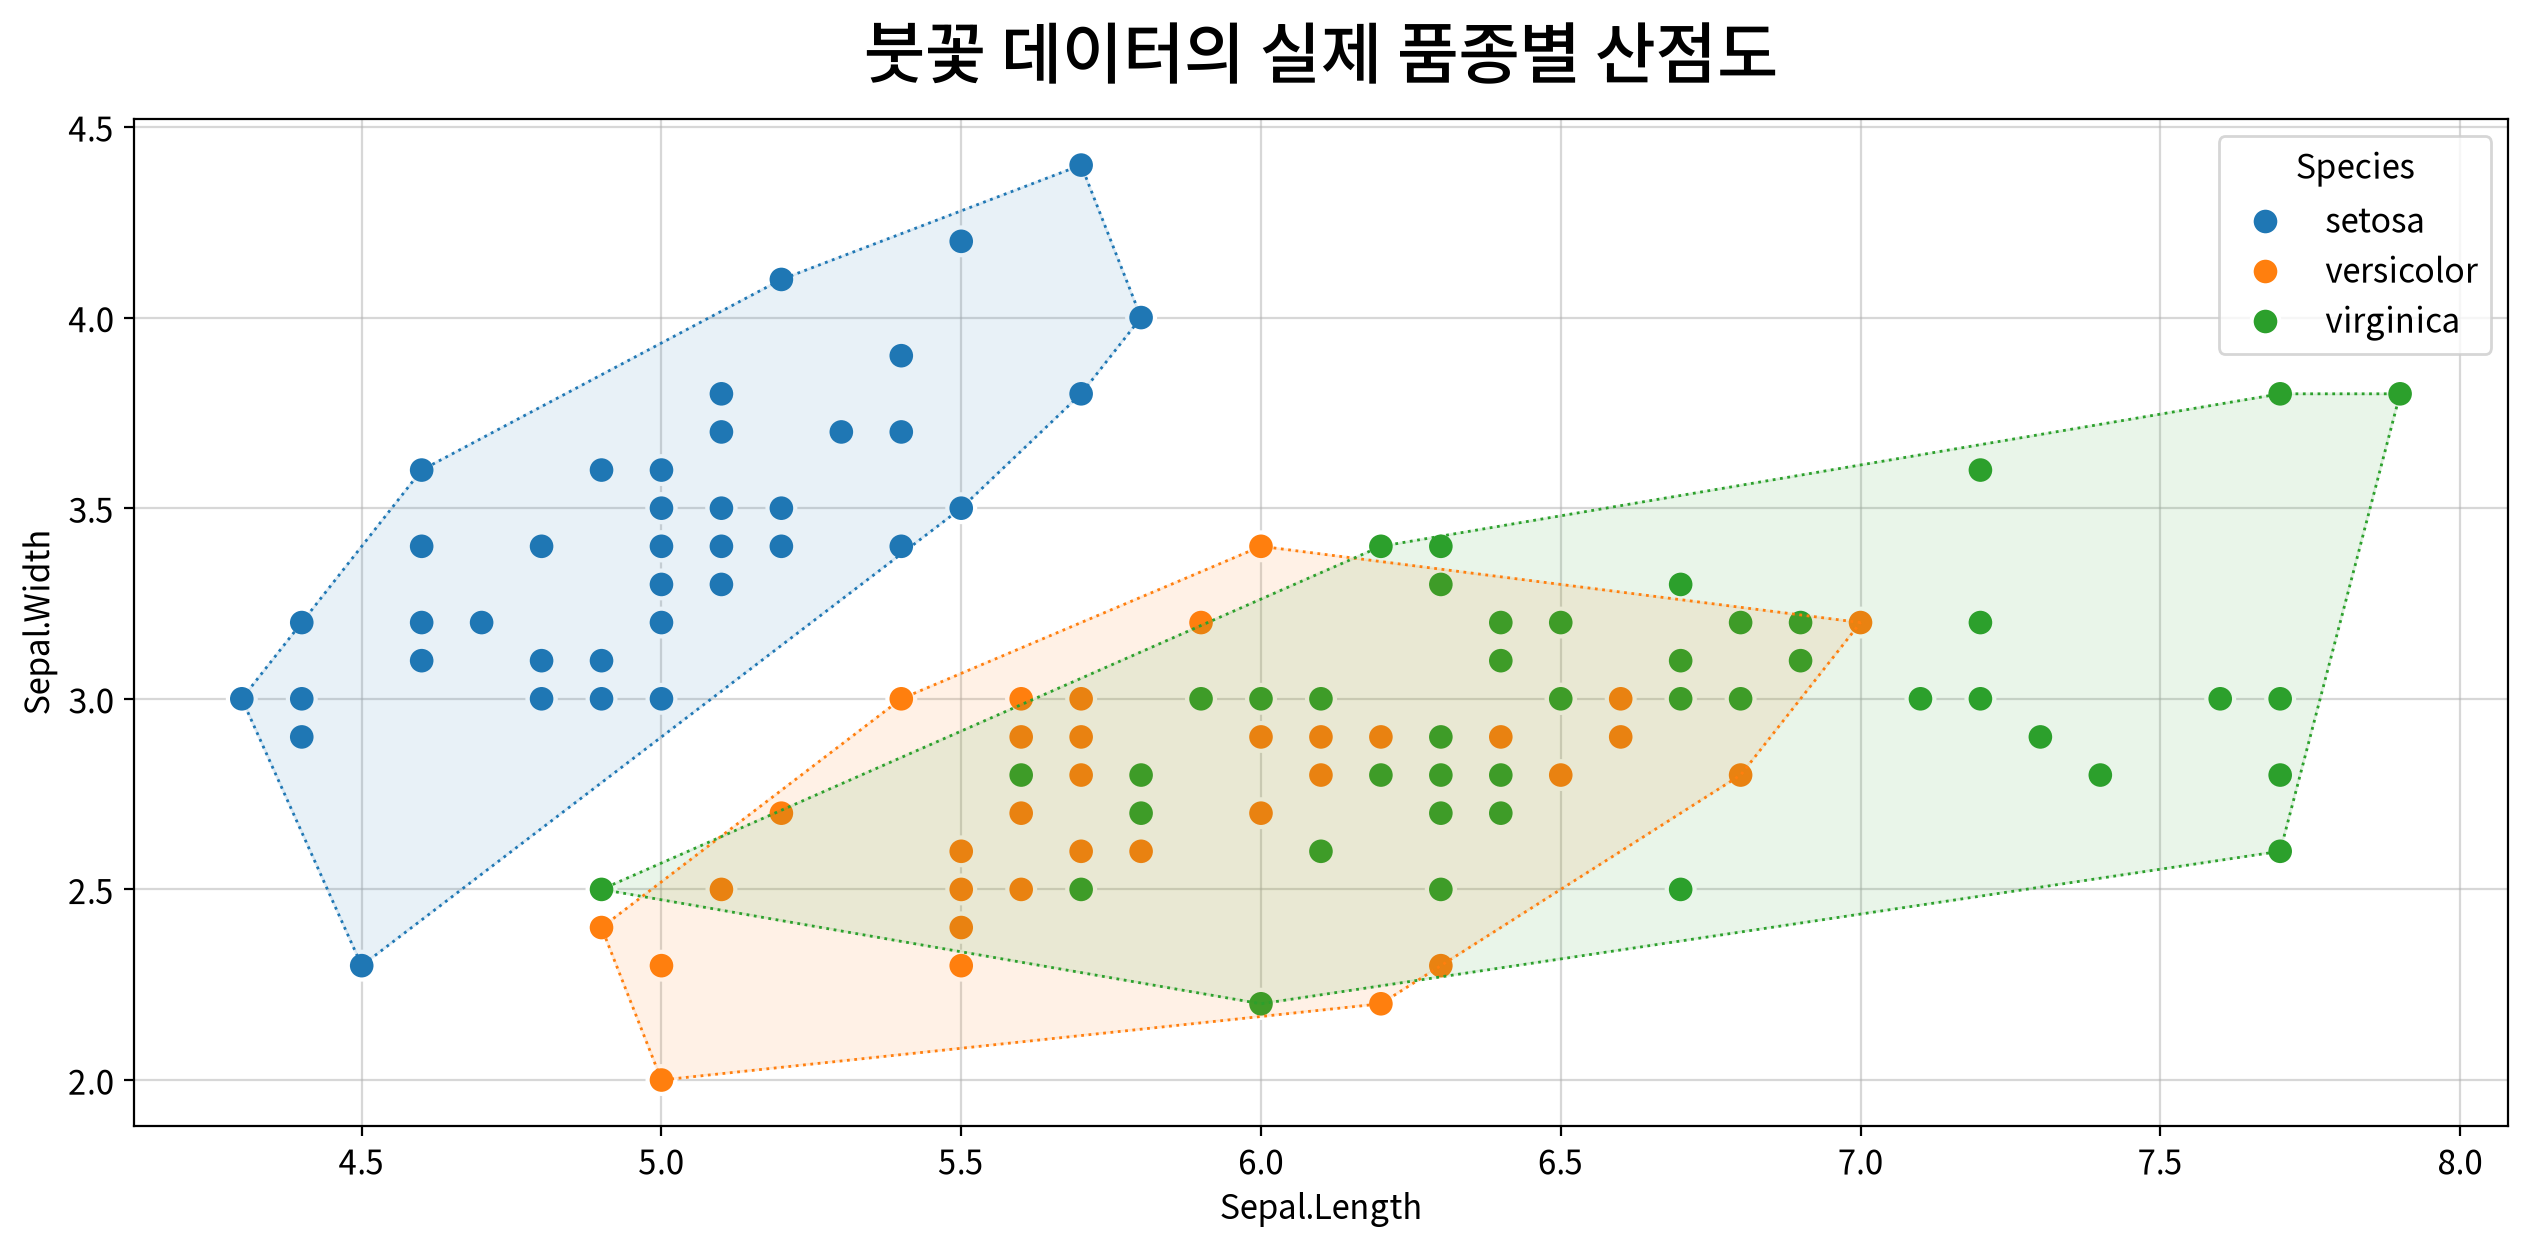

StandardScaler 적용 (4개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Sepal.Length         4.30 ~ 7.90            -1.87~2.49
Sepal.Width          2.00 ~ 4.40            -2.43~3.09
Petal.Length         1.00 ~ 6.90            -1.57~1.79
Petal.Width          0.10 ~ 2.50            -1.45~1.71


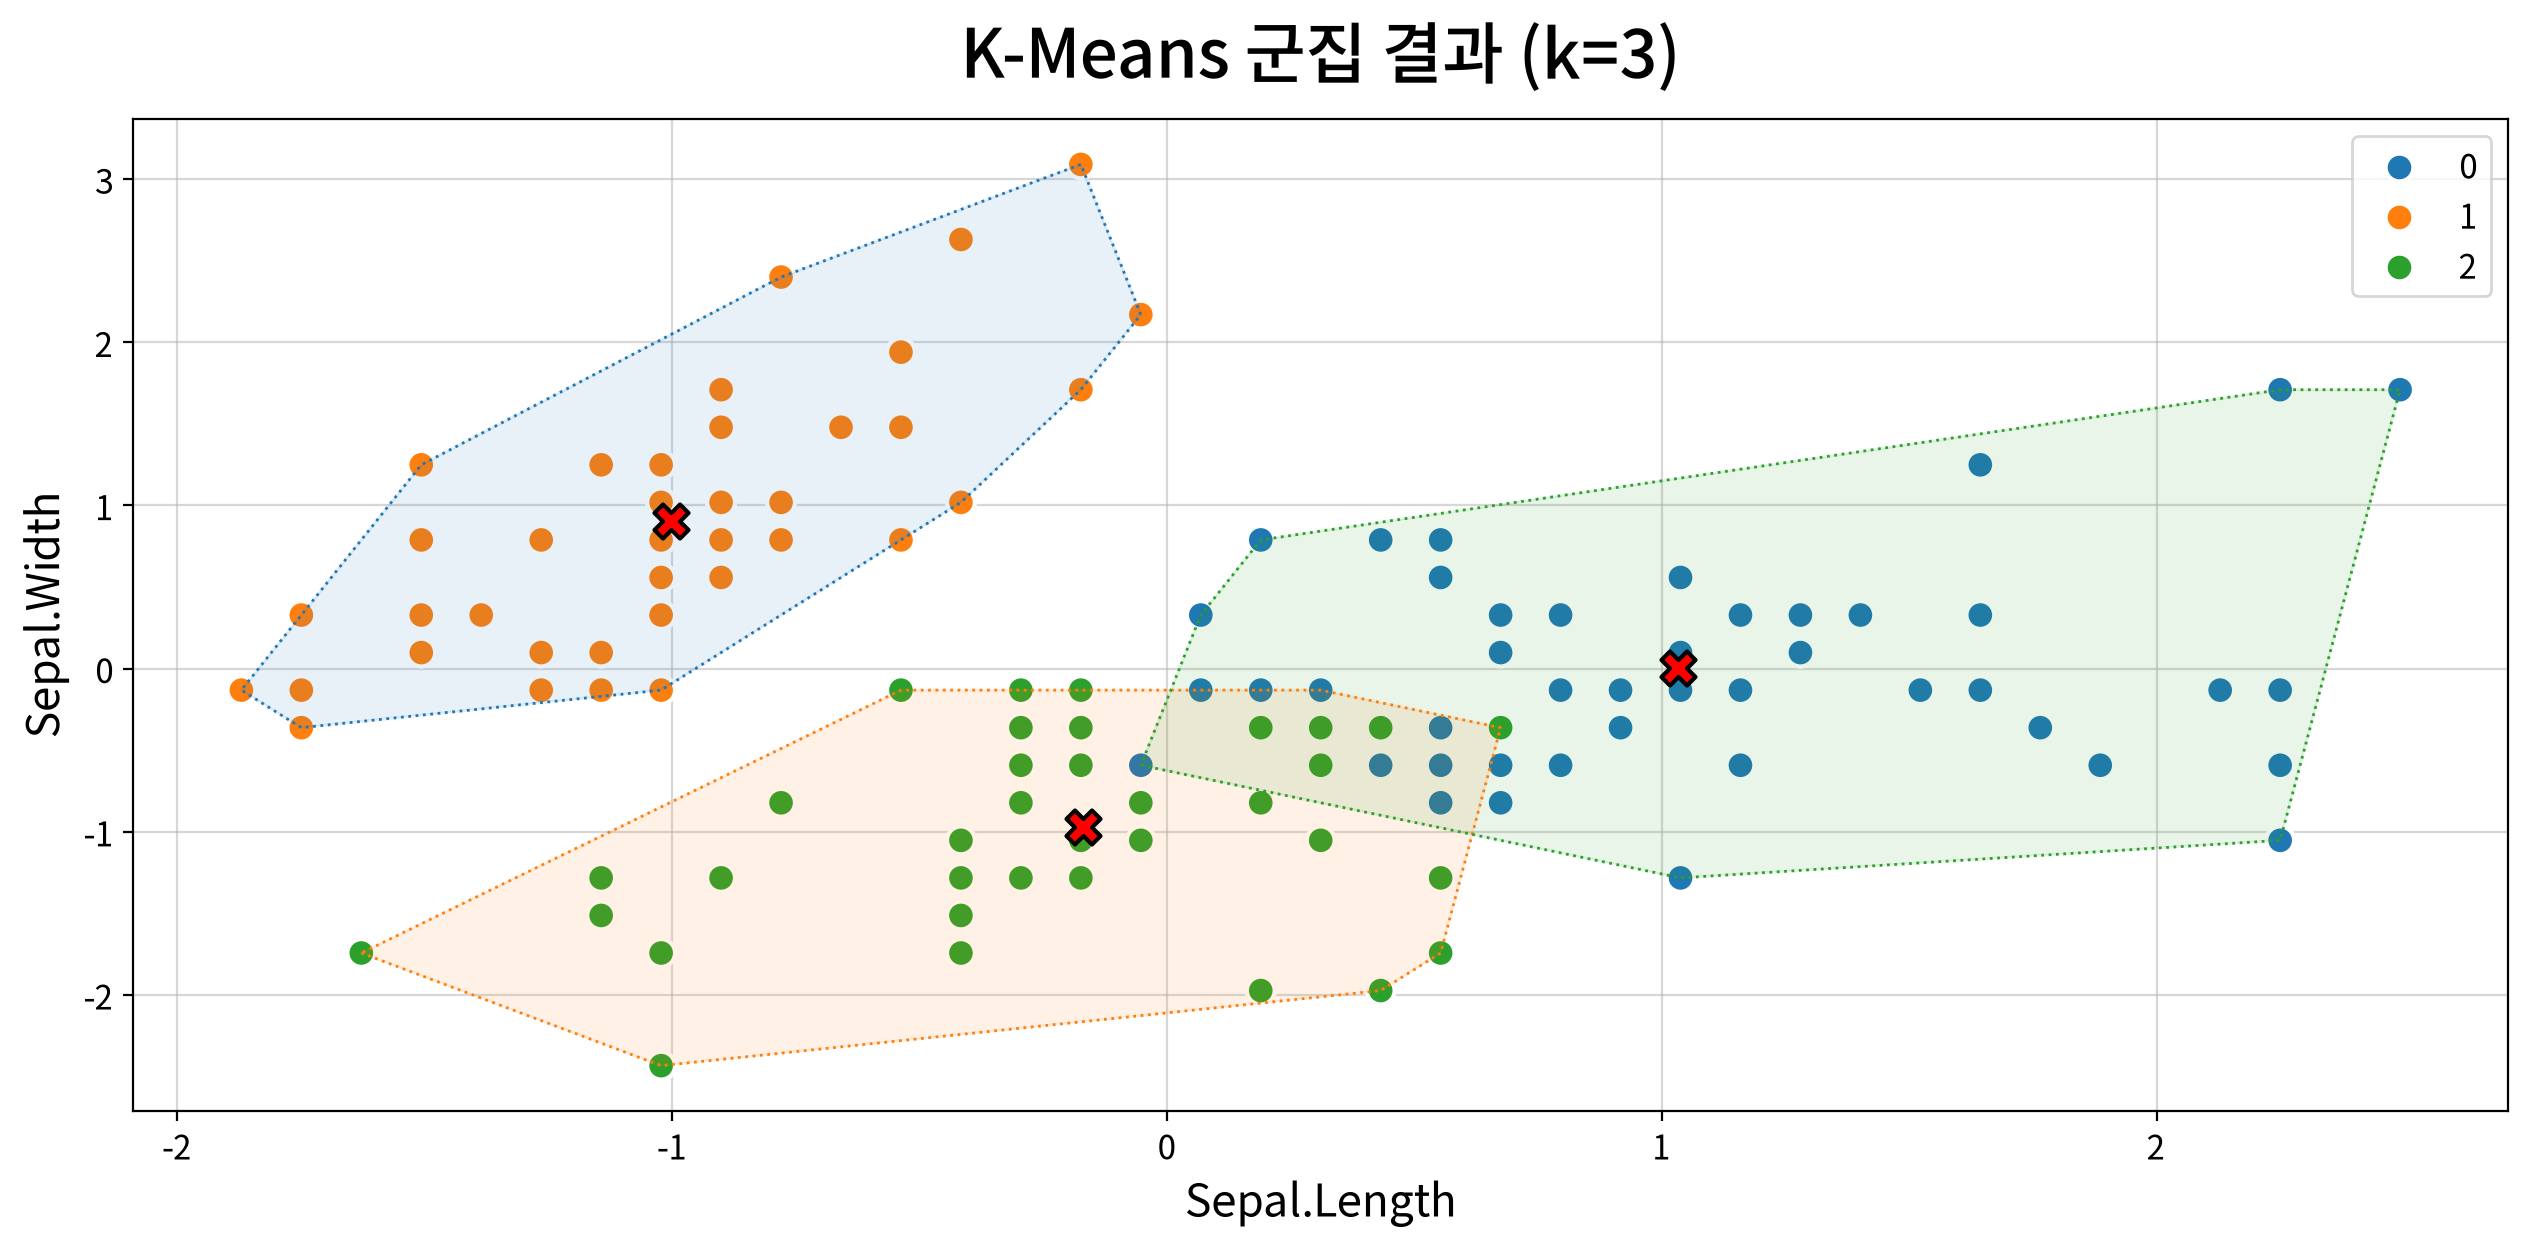

In [13]:
# 원래의 품종별 산점도
my_plot.scatterplot(data=origin, x="Sepal.Length", y="Sepal.Width",
                     hue='Species', title="붓꽃 데이터의 실제 품종별 산점도")

# 클러스터링
# --> 내부에서 스케일링을 처리하므로 종속변수를 제거한 원본을 전달한다.
estimator, _, _ = my_cluster.kmeans(df, k=3, verbose=True, plot=True)

- 한 군집은 특정 품종과 거의 완벽하게 일치한다 (setosa — 확실히 떨어져 있던 그 덩어리)
- 나머지 두 군집은 조금씩 섞여 있다 → versicolor 와 virginica 가 실제로 비슷하게 생겼기 때문
- 실루엣이 K=2를 선호했던 이유가 바로 이것이다

# # 3-2 엘보우, 실루엣 모듈화 

### 1. 엘보우 포인트 기반 best-k 찾기 

StandardScaler 적용 (4개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Sepal.Length         4.30 ~ 7.90            -1.87~2.49
Sepal.Width          2.00 ~ 4.40            -2.43~3.09
Petal.Length         1.00 ~ 6.90            -1.57~1.79
Petal.Width          0.10 ~ 2.50            -1.45~1.71
[엘보우] 최적의 k = 5


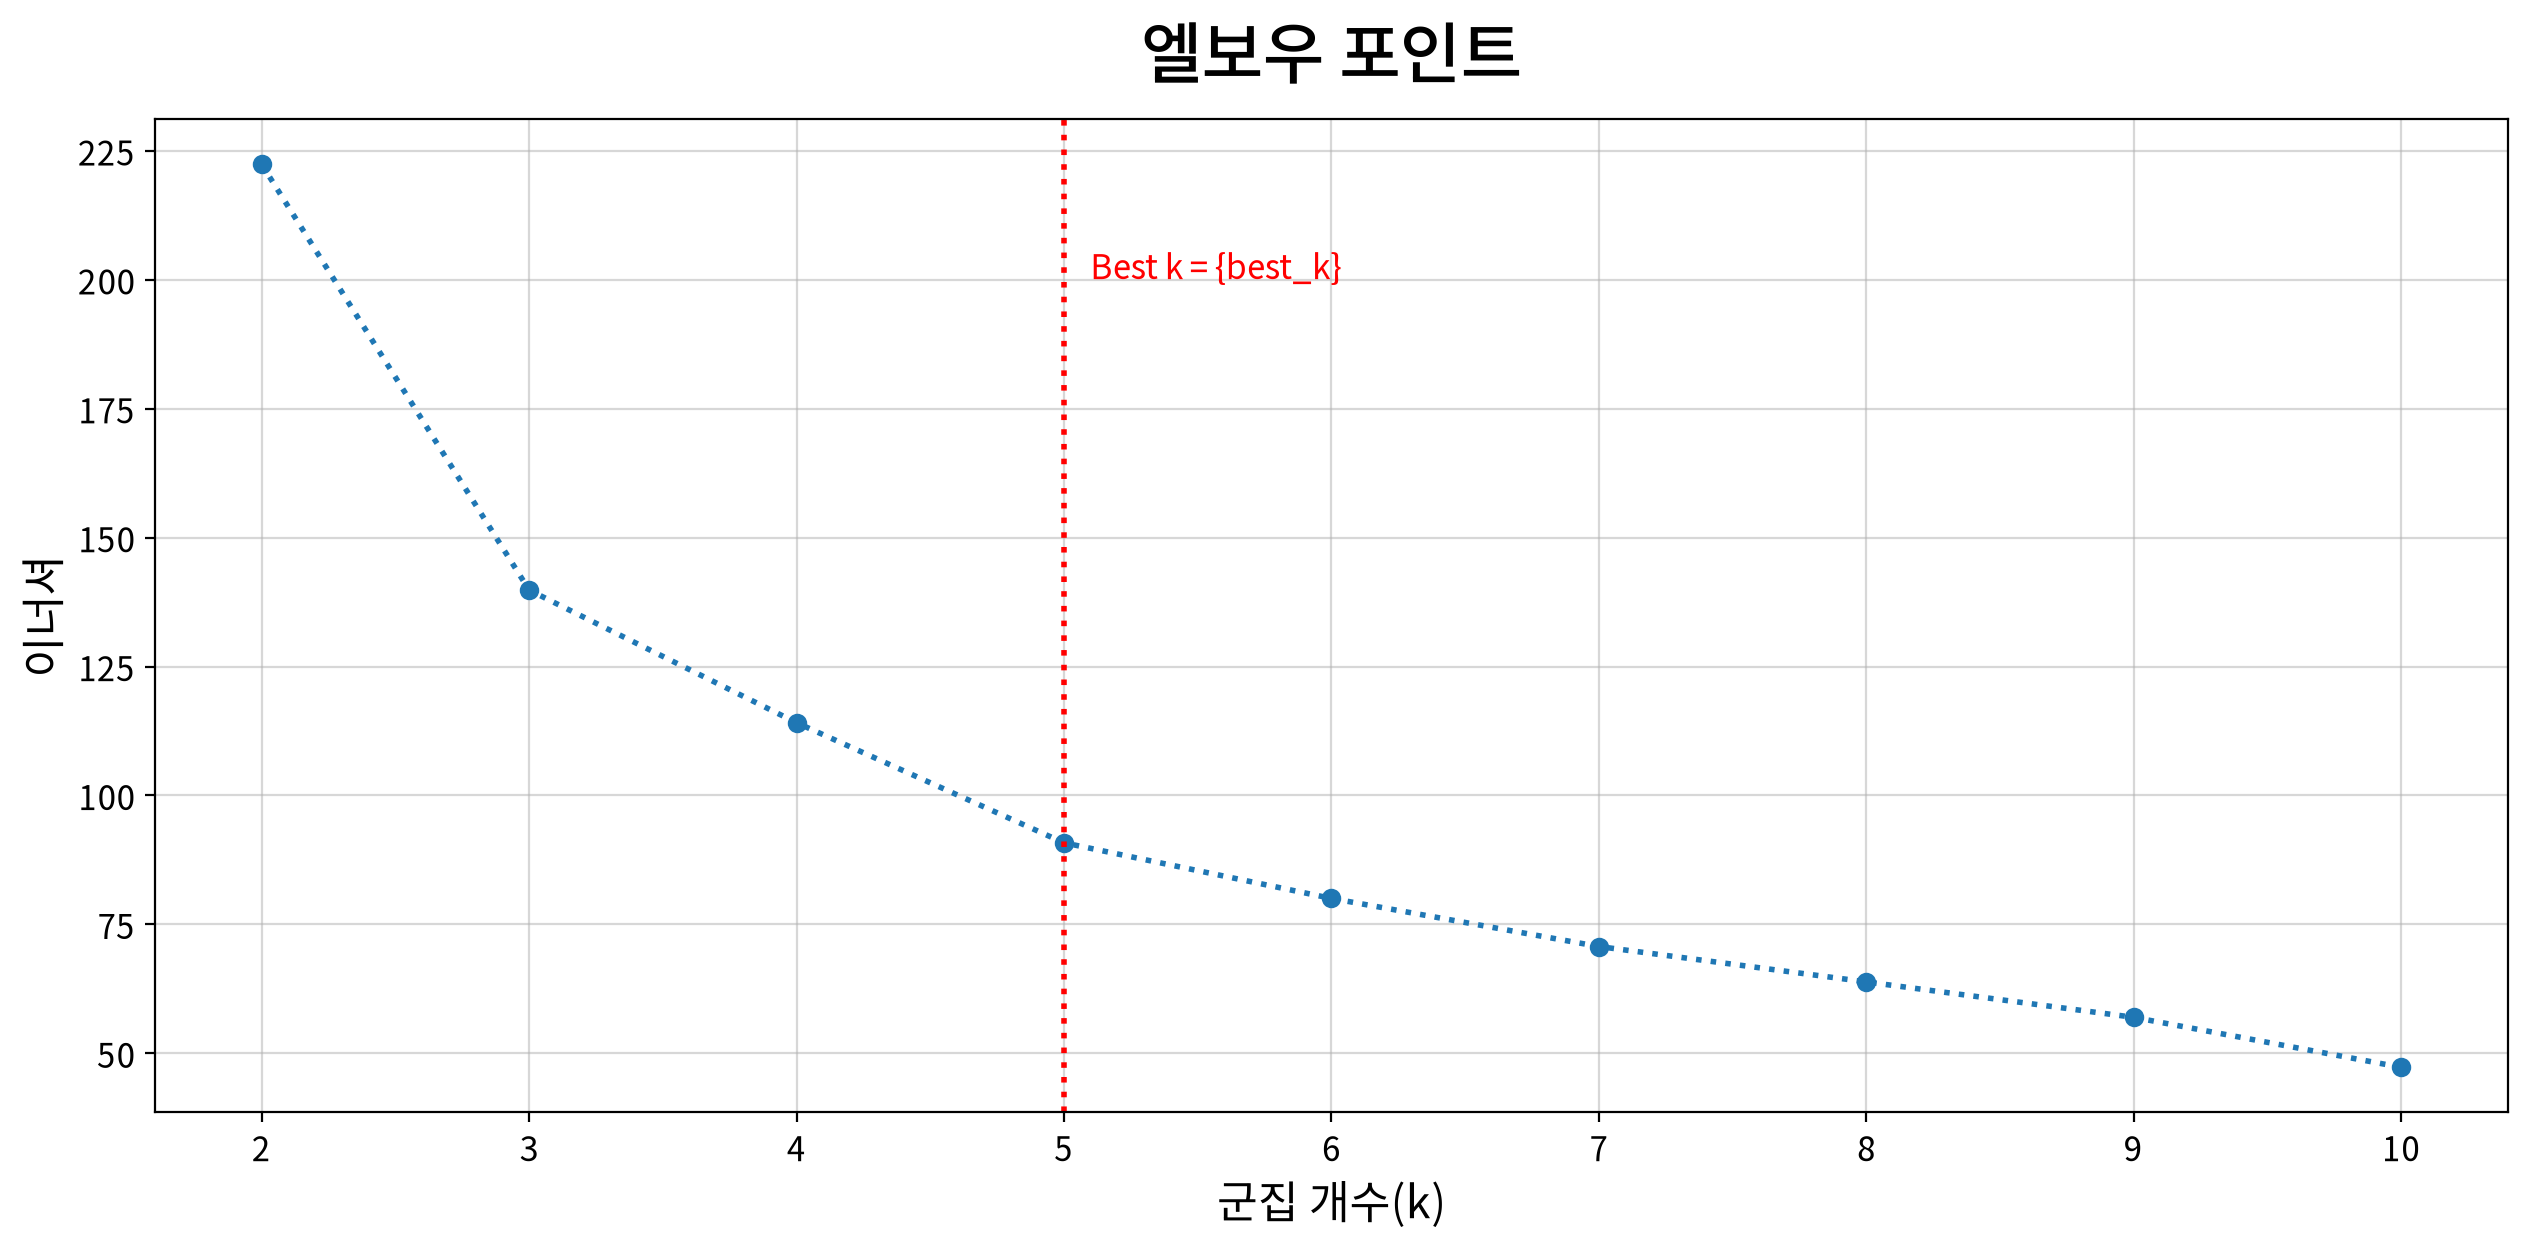

엘보우 포인트:  5


,k,이너셔,감소량
0,2,222.362,NaN
1,3,139.821,82.541
2,4,114.097,25.723
3,5,90.807,23.290
4,6,80.022,10.785
5,7,70.697,9.326
6,8,63.836,6.861
7,9,56.962,6.873
8,10,47.275,9.687


In [14]:
elbow_k, elbow_df = my_cluster.best_k_elbow(df)

print("엘보우 포인트: ", elbow_k)
elbow_df

### 2. 실루엣 스코어 기반 best-k 찾기 

StandardScaler 적용 (4개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Sepal.Length         4.30 ~ 7.90            -1.87~2.49
Sepal.Width          2.00 ~ 4.40            -2.43~3.09
Petal.Length         1.00 ~ 6.90            -1.57~1.79
Petal.Width          0.10 ~ 2.50            -1.45~1.71
[실루엣] 균형지수 최대 -> 최적의 k = 3(스코어 0.4599, 두께비 1.1277, 균형지수 0.2896)


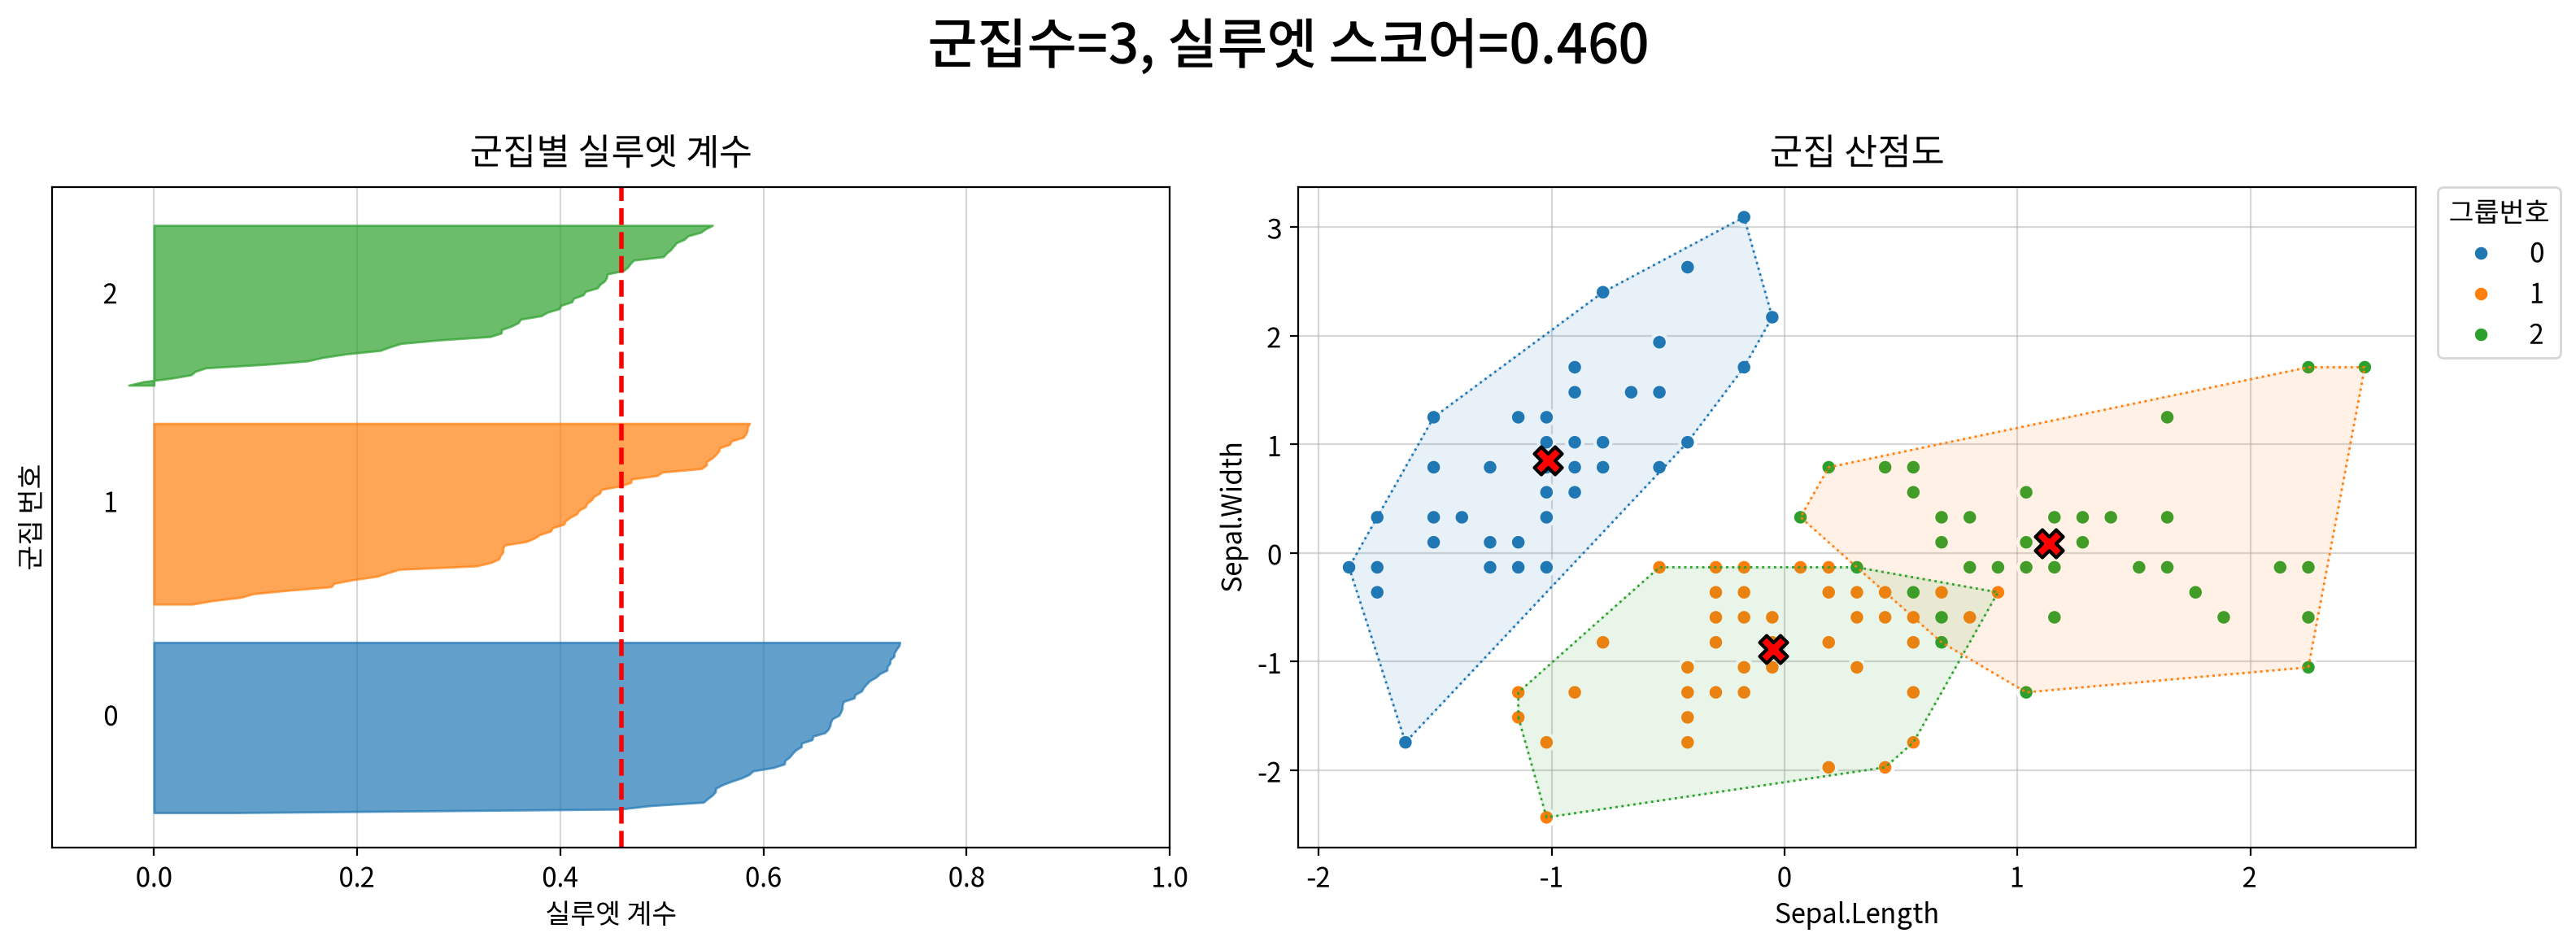

실루엣 스코어가 가장 높은 k:  3


,k,스코어,전체면적,두께비,최소상대면적,균형지수
0,2,0.582,87.263,2.000,0.780,0.227
1,3,0.460,68.992,1.128,0.710,0.290
2,4,0.384,57.525,2.080,0.649,0.120
3,5,0.342,51.292,2.087,0.802,0.131
4,6,0.326,48.852,3.083,0.286,0.030
5,7,0.326,48.844,3.250,0.310,0.031
6,8,0.323,48.370,4.857,0.257,0.017
7,9,0.366,54.944,12.000,0.254,0.008
8,10,0.351,52.709,7.000,0.294,0.015


In [15]:
# plot_each = True 설정시 모든 k에 대해 실루엣 계수를 시각화 하고, 
# plot_each = False 설정시 가장 좋은 k에 대해서만 시각화 한다. 
sil_k, sil_df = my_cluster.best_k_silhouette(df)

print("실루엣 스코어가 가장 높은 k: ", sil_k)
sil_df